# Results Visualisation

Charts comparing all RAG architectures across retrieval, generation, faithfulness, correctness, clinical safety, and latency metrics. All figures are thesis-ready (high DPI, clean formatting, consistent colour scheme).

In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import config

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (10, 6),
})

FIGURES_DIR = config.RESULTS_FIGURES_DIR
RAGAS_DIR = config.RESULTS_RAGAS_DIR
DEEPEVAL_DIR = config.RESULTS_DEEPEVAL_DIR
EVAL_DIR = config.RESULTS_EVALSETS_DIR

## Load All Metrics into a Unified DataFrame

In [9]:
# Architecture labels and their file prefixes
ARCHITECTURES = {
    "Vanilla LLM":             {"ragas": "vanilla_llm_combined_20260505_175240.csv", "eval": "vanilla_llm_20260505_175240.csv"},
    "Vanilla LLM + Critic":    {"ragas": "vanilla_llm_critic_combined_20260510_140037.csv", "eval": "vanilla_llm_critic_20260510_140037.csv", "corr": "vanilla_llm_critic_answer_correctness_20260510_140037.csv"},
    "Naive RAG k=3":           {"ragas": "naive_rag_minilm_combined_20260504_132359.csv", "eval": "naive_rag_minilm_chroma_cosine_20260504_132359.csv", "faith": "naive_rag_minilm_faithfulness_20260504_132359.csv", "corr": "naive_rag_minilm_answer_correctness_20260504_132359.csv"},
    "Naive RAG k=5":           {"ragas": "naive_rag_minilm_k_5_combined_20260506_145734.csv", "eval": "naive_rag_minilm_chroma_cosine_k_5_20260506_145734.csv", "faith": "naive_rag_minilm_k_5_faithfulness_20260506_145734.csv", "corr": "naive_rag_minilm_k_5_answer_correctness_20260506_145734.csv"},
    "Naive RAG k=8":           {"ragas": "naive_rag_minilm_k_8_combined_20260507_145335.csv", "eval": "naive_rag_minilm_chroma_cosine_k_8_20260507_145335.csv", "faith": "naive_rag_minilm_k_8_faithfulness_20260507_145335.csv", "corr": "naive_rag_minilm_k_8_answer_correctness_20260507_145335.csv"},
    "Query Expansion (Single)":     {"ragas": "query_expansion_rag_minilm_combined_20260509_121158.csv", "eval": "query_expansion_rag_minilm_chroma_cosine_20260509_121158.csv", "faith": "query_expansion_rag_minilm_faithfulness_20260509_121158.csv", "corr": "query_expansion_rag_minilm_answer_correctness_20260509_121158.csv"},
    "Query Expansion (Multi)":      {"ragas": "multi_query_expansion_rag_minilm_combined_20260509_155059.csv", "eval": "multi_query_expansion_rag_minilm_chroma_cosine_20260509_155059.csv", "faith": "multi_query_expansion_rag_minilm_faithfulness_20260509_155059.csv", "corr": "multi_query_expansion_rag_minilm_answer_correctness_20260509_155059.csv"},
    "Query Decomposition":     {"ragas": "decomposition_rag_minilm_combined_20260518_181816.csv", "eval": "decomposition_rag_minilm_k_5_20260518_181816.csv", "faith": "decomposition_rag_minilm_faithfulness_20260518_181816.csv", "corr": "decomposition_rag_minilm_answer_correctness_20260518_181816.csv"},
    "Hybrid RRF":              {"ragas": "hybrid_rrf_rag_minilm_combined_20260510_081037.csv", "eval": "hybrid_rrf_rag_minilm_chroma_cosine_20260510_081037.csv", "faith": "hybrid_rrf_rag_minilm_faithfulness_20260510_081037.csv", "corr": "hybrid_rrf_rag_minilm_answer_correctness_20260510_081037.csv"},
    "Hybrid + Cross-Encoder":  {"ragas": "hybrid_cross_encoder_rag_minilm_combined_20260510_062636.csv", "eval": "hybrid_cross_encoder_rag_minilm_chroma_cosine_20260510_062636.csv", "faith": "hybrid_cross_encoder_rag_minilm_faithfulness_20260510_062636.csv", "corr": "hybrid_cross_encoder_rag_minilm_answer_correctness_20260510_062636.csv"},
    "Naive RAG With Critic":      {"ragas": "naive_rag_critic_minilm_combined_20260517_204517.csv", "eval": "naive_rag_critic_minilm_chroma_cosine_20260517_204517.csv", "faith": "naive_rag_critic_minilm_faithfulness_20260517_204517.csv", "corr": "naive_rag_critic_minilm_answer_correctness_20260517_204517.csv"},
    "MeSH-Guided RAG":        {"ragas": "mesh_guided_rag_minilm_combined_20260512_132445.csv", "eval": "mesh_guided_rag_minilm_chroma_20260512_132445.csv", "faith": "mesh_guided_rag_minilm_faithfulness_20260512_132445.csv", "corr": "mesh_guided_rag_minilm_answer_correctness_20260512_132445.csv"},
    "Evidence-Graded RAG":     {"ragas": "evidence_graded_rag_minilm_combined_20260516_164252.csv", "eval": "evidence_graded_rag_minilm_chroma_20260516_164252.csv", "faith": "evidence_graded_rag_minilm_faithfulness_20260516_164252.csv", "corr": "evidence_graded_rag_minilm_answer_correctness_20260516_164252.csv"},
}

def safe_mean(df, col_keyword):
    cols = [c for c in df.columns if col_keyword.lower() in c.lower()]
    if cols:
        return df[cols[0]].mean()
    return np.nan

rows = []
for label, files in ARCHITECTURES.items():
    row = {"Architecture": label}

    # RAGAS metrics
    ragas_path = RAGAS_DIR / files["ragas"]
    if ragas_path.exists():
        rdf = pd.read_csv(ragas_path)
        row["BLEU"] = safe_mean(rdf, "BleuScore")
        row["ROUGE-L"] = safe_mean(rdf, "RougeScore")
        row["Context Recall (RAGAS)"] = safe_mean(rdf, "NonLLMContextRecall")
        row["Context Precision (RAGAS)"] = safe_mean(rdf, "NonLLMContextPrecisionWithReference")

    # Eval dataset (latency)
    eval_path = EVAL_DIR / files["eval"]
    if eval_path.exists():
        edf = pd.read_csv(eval_path)
        if "total_time" in edf.columns:
            row["Mean Latency (s)"] = edf["total_time"].mean()
        if "total_tokens" in edf.columns:
            row["Mean Tokens"] = edf["total_tokens"].mean()

    # DeepEval faithfulness
    if "faith" in files:
        fpath = DEEPEVAL_DIR / files["faith"]
        if fpath.exists():
            fdf = pd.read_csv(fpath)
            row["Faithfulness"] = safe_mean(fdf, "faith")

    # DeepEval answer correctness
    if "corr" in files:
        cpath = DEEPEVAL_DIR / files["corr"]
        if cpath.exists():
            cdf = pd.read_csv(cpath)
            row["Answer Correctness"] = safe_mean(cdf, "correct")

    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index("Architecture")

# Add CWHS/CSS data
cwhs_path = FIGURES_DIR / "cwhs_summary.csv"
if cwhs_path.exists():
    cwhs_df = pd.read_csv(cwhs_path).set_index("Architecture")
    for col in ["CWHS", "Δ (CWHS − Unweighted)"]:
        if col in cwhs_df.columns:
            metrics_df[col] = cwhs_df[col]

print("Unified metrics DataFrame:")
metrics_df

Unified metrics DataFrame:


,BLEU,ROUGE-L,Context Recall (RAGAS),Context Precision (RAGAS),Mean Latency (s),Mean Tokens,Answer Correctness,Faithfulness,CWHS,Δ (CWHS − Unweighted)
Architecture,,,,,,,,,,
Vanilla LLM,0.075741,0.211349,NaN,NaN,0.517527,173.525000,NaN,NaN,NaN,NaN
Vanilla LLM + Critic,0.084940,0.075124,NaN,NaN,7.303272,2425.205128,0.3210,NaN,NaN,NaN
Naive RAG k=3,0.185288,0.309834,0.180417,0.297917,NaN,NaN,0.6685,0.985905,0.0148,0.0007
Naive RAG k=5,0.173740,0.296624,0.200833,0.306667,NaN,NaN,0.7150,0.979607,0.0200,-0.0003
Naive RAG k=8,0.179665,0.305132,0.213750,0.306131,NaN,NaN,0.6680,0.985232,0.0137,-0.0011
Query Expansion (Single),0.174142,0.286659,0.208333,0.320167,6.001575,1852.850000,0.6795,0.985524,0.0141,-0.0003
Query Expansion (Multi),0.171219,0.297973,0.209583,0.307750,5.432509,2049.320000,0.7385,0.988119,0.0132,0.0013
Query Decomposition,0.172887,0.300827,0.210000,0.311083,3.757946,2089.360000,0.7475,0.984905,0.0163,0.0012
Hybrid RRF,0.169784,0.297043,0.196667,0.286111,4.240257,1804.780000,0.6955,0.981405,0.0198,0.0013


## Chart 1: Generation Quality — BLEU and ROUGE-L Across Architectures

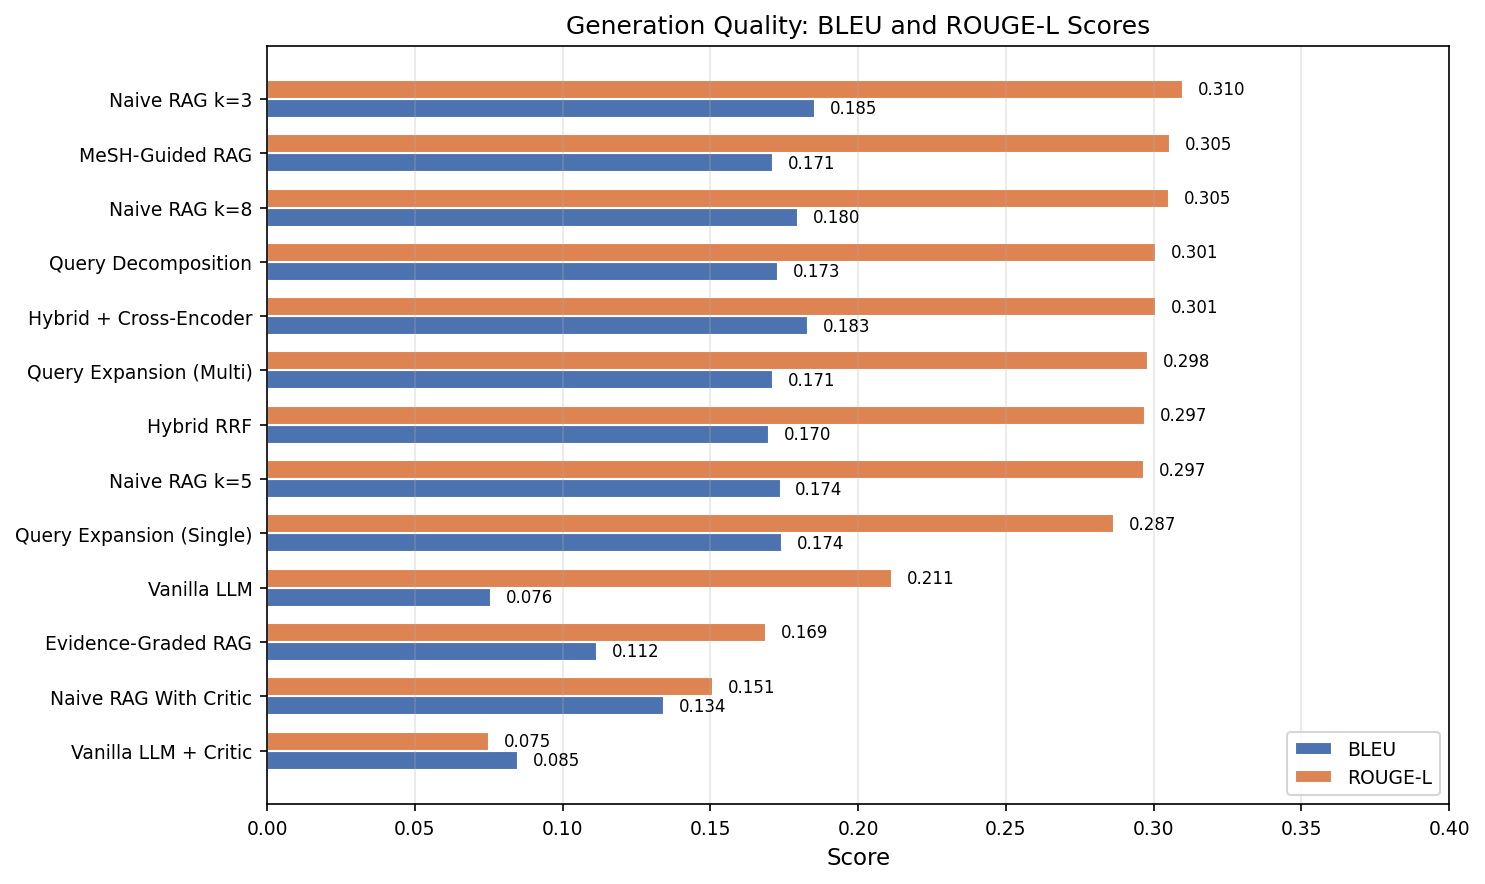

In [10]:
gen_df = metrics_df[["BLEU", "ROUGE-L"]].dropna(how="all").sort_values("ROUGE-L", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(gen_df))
bar_height = 0.35

bars1 = ax.barh(y - bar_height/2, gen_df["BLEU"], bar_height, label="BLEU", color="#4C72B0", edgecolor="white")
bars2 = ax.barh(y + bar_height/2, gen_df["ROUGE-L"], bar_height, label="ROUGE-L", color="#DD8452", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(gen_df.index)
ax.set_xlabel("Score")
ax.set_title("Generation Quality: BLEU and ROUGE-L Scores")
ax.legend(loc="lower right")
ax.set_xlim(0, 0.40)
ax.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_generation_quality.png", bbox_inches="tight")
plt.show()

## Chart 2: Retrieval Quality — Context Recall and Precision (RAGAS)

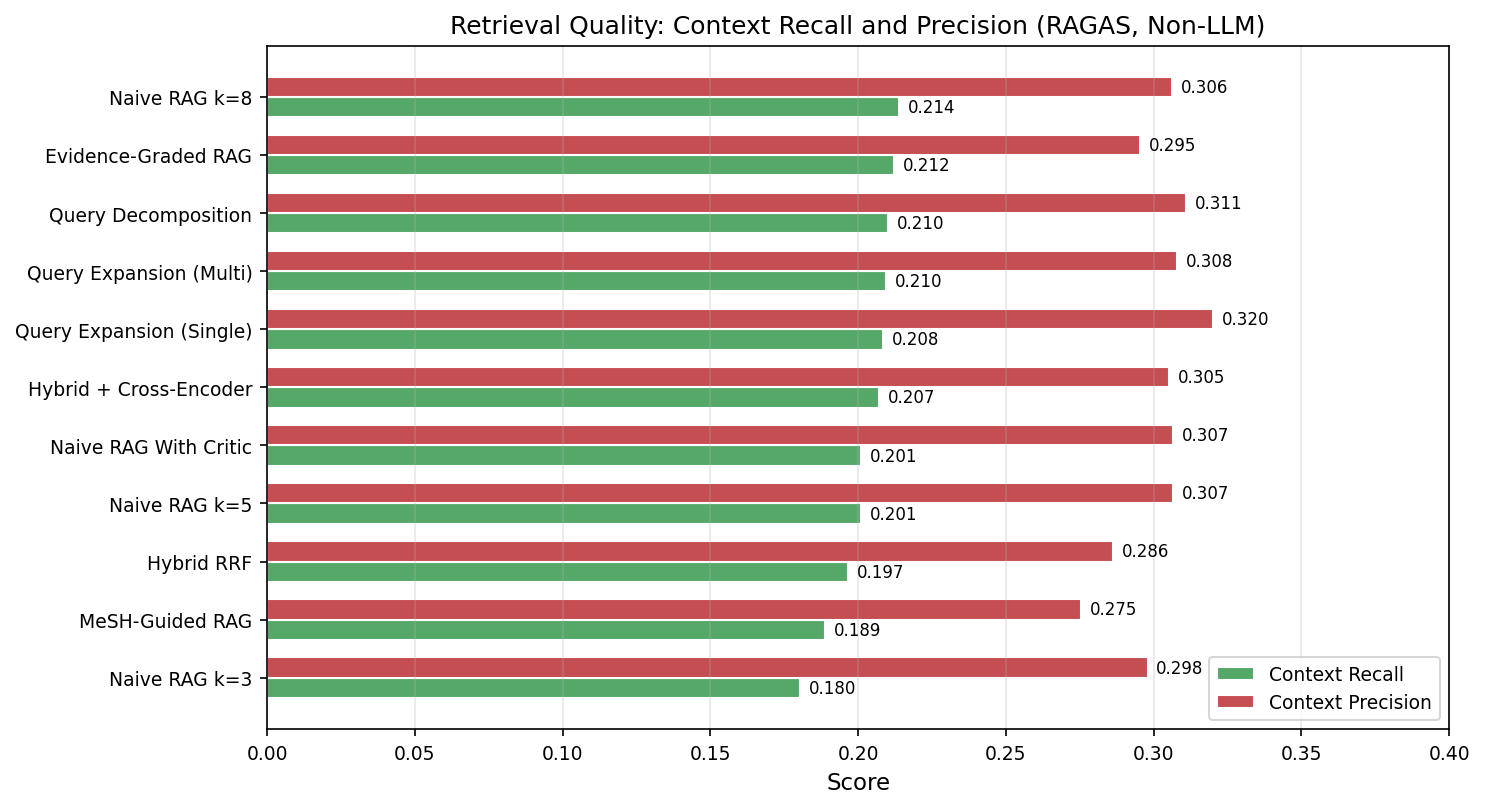

In [11]:
ret_df = metrics_df[["Context Recall (RAGAS)", "Context Precision (RAGAS)"]].dropna(how="all").sort_values("Context Recall (RAGAS)", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(ret_df))
bar_height = 0.35

bars1 = ax.barh(y - bar_height/2, ret_df["Context Recall (RAGAS)"], bar_height, label="Context Recall", color="#55A868", edgecolor="white")
bars2 = ax.barh(y + bar_height/2, ret_df["Context Precision (RAGAS)"], bar_height, label="Context Precision", color="#C44E52", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(ret_df.index)
ax.set_xlabel("Score")
ax.set_title("Retrieval Quality: Context Recall and Precision (RAGAS, Non-LLM)")
ax.legend(loc="lower right")
ax.set_xlim(0, 0.40)
ax.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_retrieval_quality.png", bbox_inches="tight")
plt.show()

## Chart 3: Faithfulness vs Answer Correctness Scatter Plot

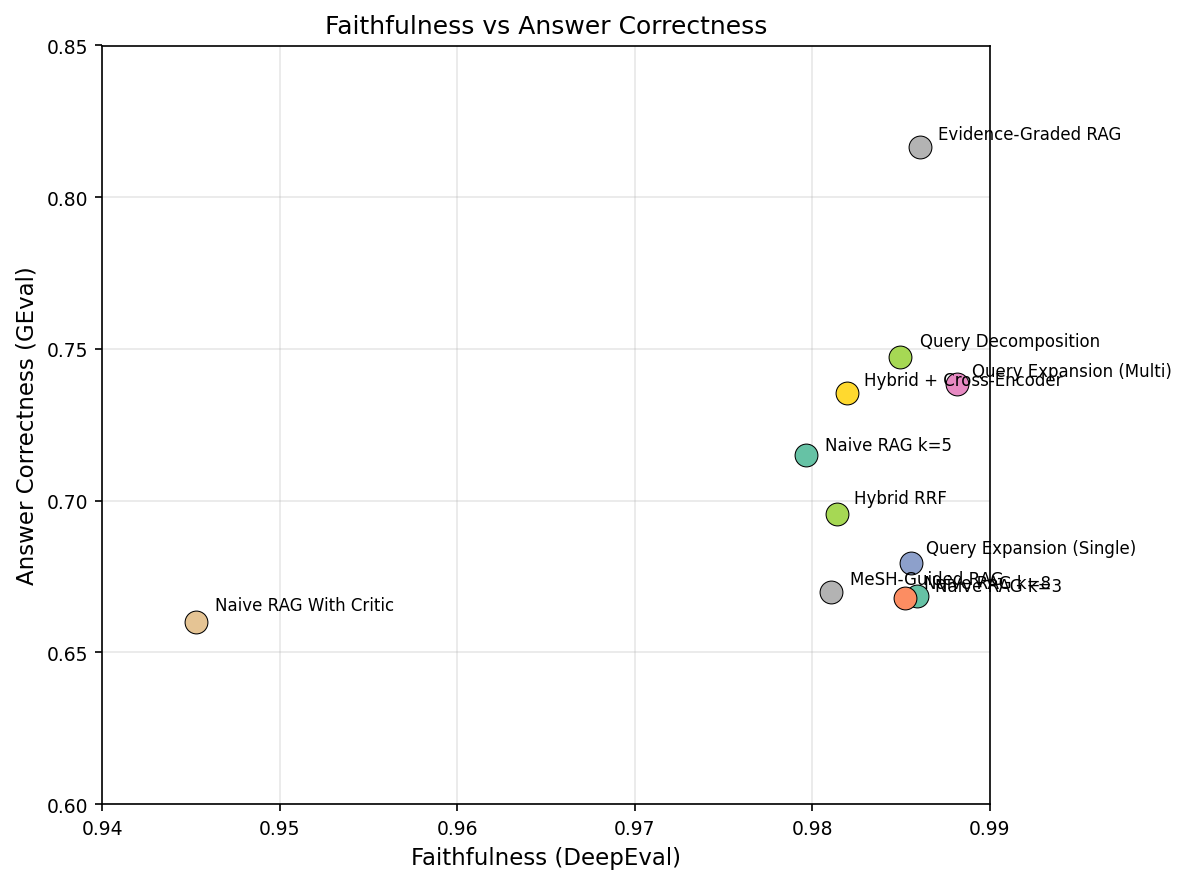

In [17]:
scatter_df = metrics_df[["Faithfulness", "Answer Correctness"]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(scatter_df)))
for i, (arch, row) in enumerate(scatter_df.iterrows()):
    ax.scatter(row["Faithfulness"], row["Answer Correctness"], s=120, c=[colors[i]], edgecolors="black", linewidth=0.5, zorder=3)
    text_pos_x = 8 + np.random.uniform(-2, 2)
    text_pos_y = 4 + np.random.uniform(-2, )
    ax.annotate(arch, (row["Faithfulness"], row["Answer Correctness"]),
                textcoords="offset points", xytext=(text_pos_x, text_pos_y), fontsize=8, ha="left")

ax.set_xlabel("Faithfulness (DeepEval)")
ax.set_ylabel("Answer Correctness (GEval)")
ax.set_title("Faithfulness vs Answer Correctness")
ax.grid(alpha=0.3)
ax.set_xlim(0.94, 0.99)
ax.set_ylim(0.60, 0.85)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_faithfulness_vs_correctness.png", bbox_inches="tight")
plt.show()

## Chart 4: Latency vs Answer Correctness Trade-off

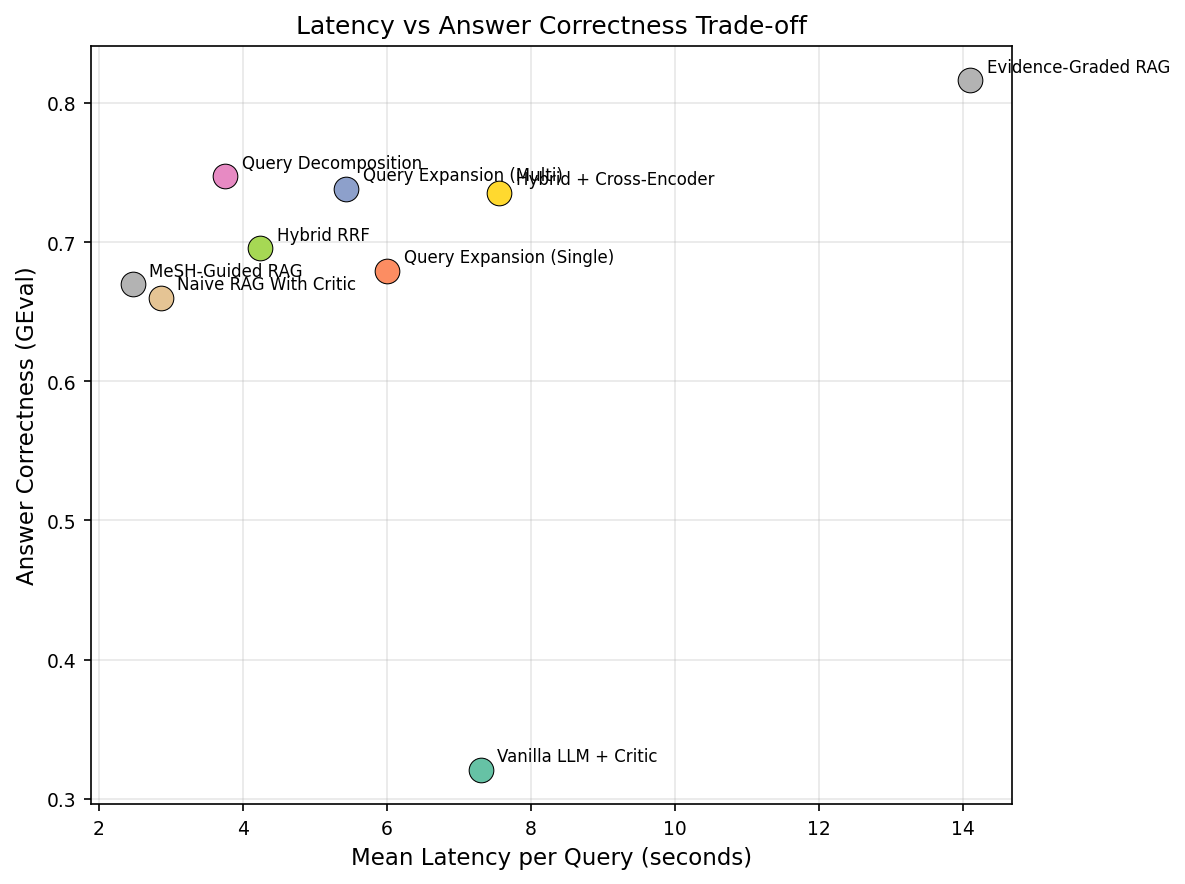

In [21]:
latency_df = metrics_df[["Mean Latency (s)", "Answer Correctness"]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(latency_df)))
for i, (arch, row) in enumerate(latency_df.iterrows()):
    ax.scatter(row["Mean Latency (s)"], row["Answer Correctness"], s=140, c=[colors[i]], edgecolors="black", linewidth=0.5, zorder=3)
    ax.annotate(arch, (row["Mean Latency (s)"], row["Answer Correctness"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8, ha="left")

ax.set_xlabel("Mean Latency per Query (seconds)")
ax.set_ylabel("Answer Correctness (GEval)")
ax.set_title("Latency vs Answer Correctness Trade-off")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_latency_vs_correctness.png", bbox_inches="tight")
plt.show()

## Chart 5: Radar Chart — Multi-Metric Architecture Comparison

Compares the top 5 architectures across 5 normalised dimensions:
Faithfulness, Answer Correctness, Context Recall (RAGAS), ROUGE-L, and Clinical Safety (1 - CWHS).

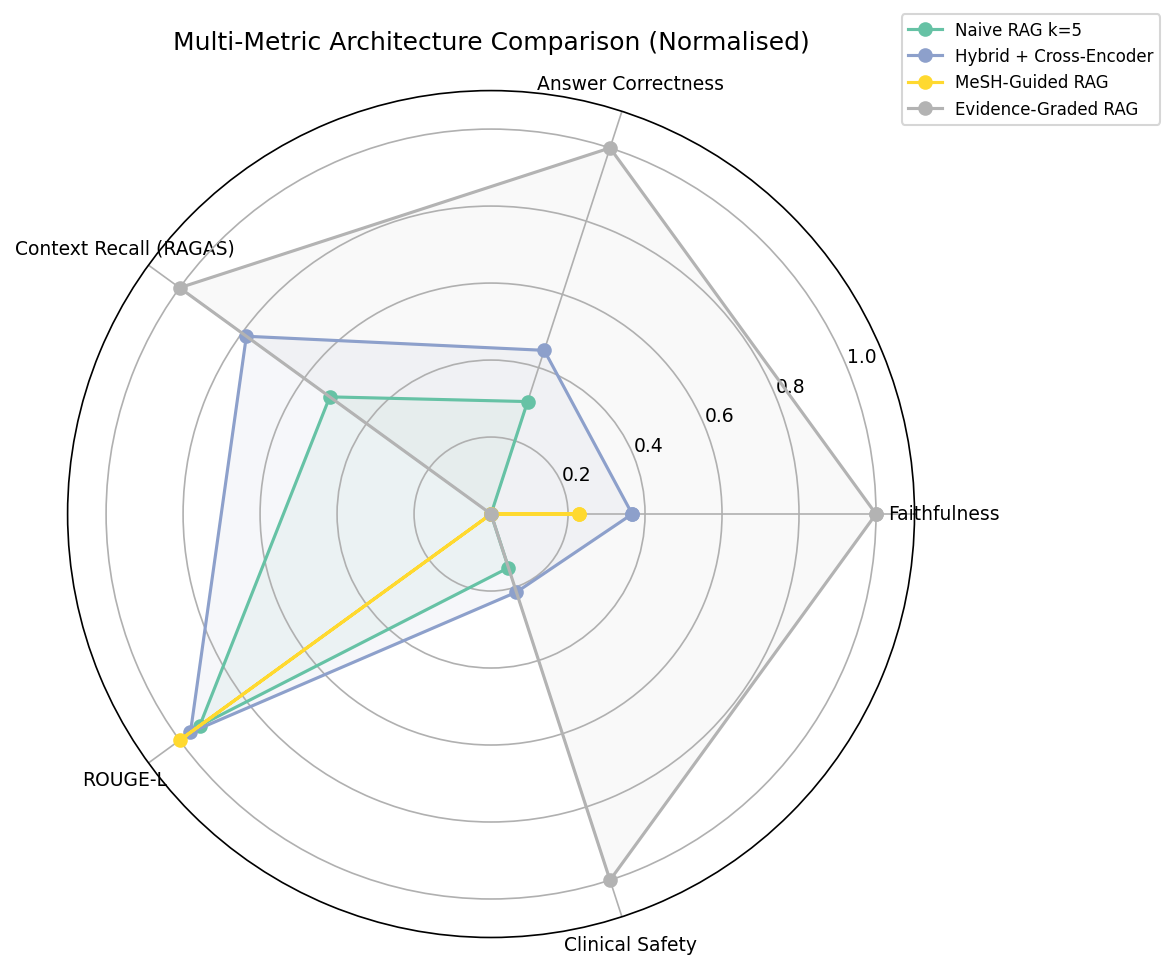

In [22]:
radar_archs = ["Query Exp. (Multi)", "Hybrid + Cross-Encoder", "Naive RAG k=5", "Evidence-Graded RAG", "MeSH-Guided RAG"]
radar_metrics = ["Faithfulness", "Answer Correctness", "Context Recall (RAGAS)", "ROUGE-L"]

radar_df = metrics_df.loc[metrics_df.index.isin(radar_archs), radar_metrics].copy()
if "CWHS" in metrics_df.columns:
    radar_df["Clinical Safety"] = 1 - metrics_df.loc[radar_df.index, "CWHS"]

# Normalise each column to [0, 1] for radar
for col in radar_df.columns:
    cmin, cmax = radar_df[col].min(), radar_df[col].max()
    if cmax > cmin:
        radar_df[col] = (radar_df[col] - cmin) / (cmax - cmin)
    else:
        radar_df[col] = 1.0

categories = list(radar_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = plt.cm.Set2(np.linspace(0, 1, len(radar_df)))

for i, (arch, row) in enumerate(radar_df.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=arch, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Multi-Metric Architecture Comparison (Normalised)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_radar_comparison.png", bbox_inches="tight")
plt.show()

## Chart 6: Naive RAG k Sensitivity — Effect of Retrieval Depth

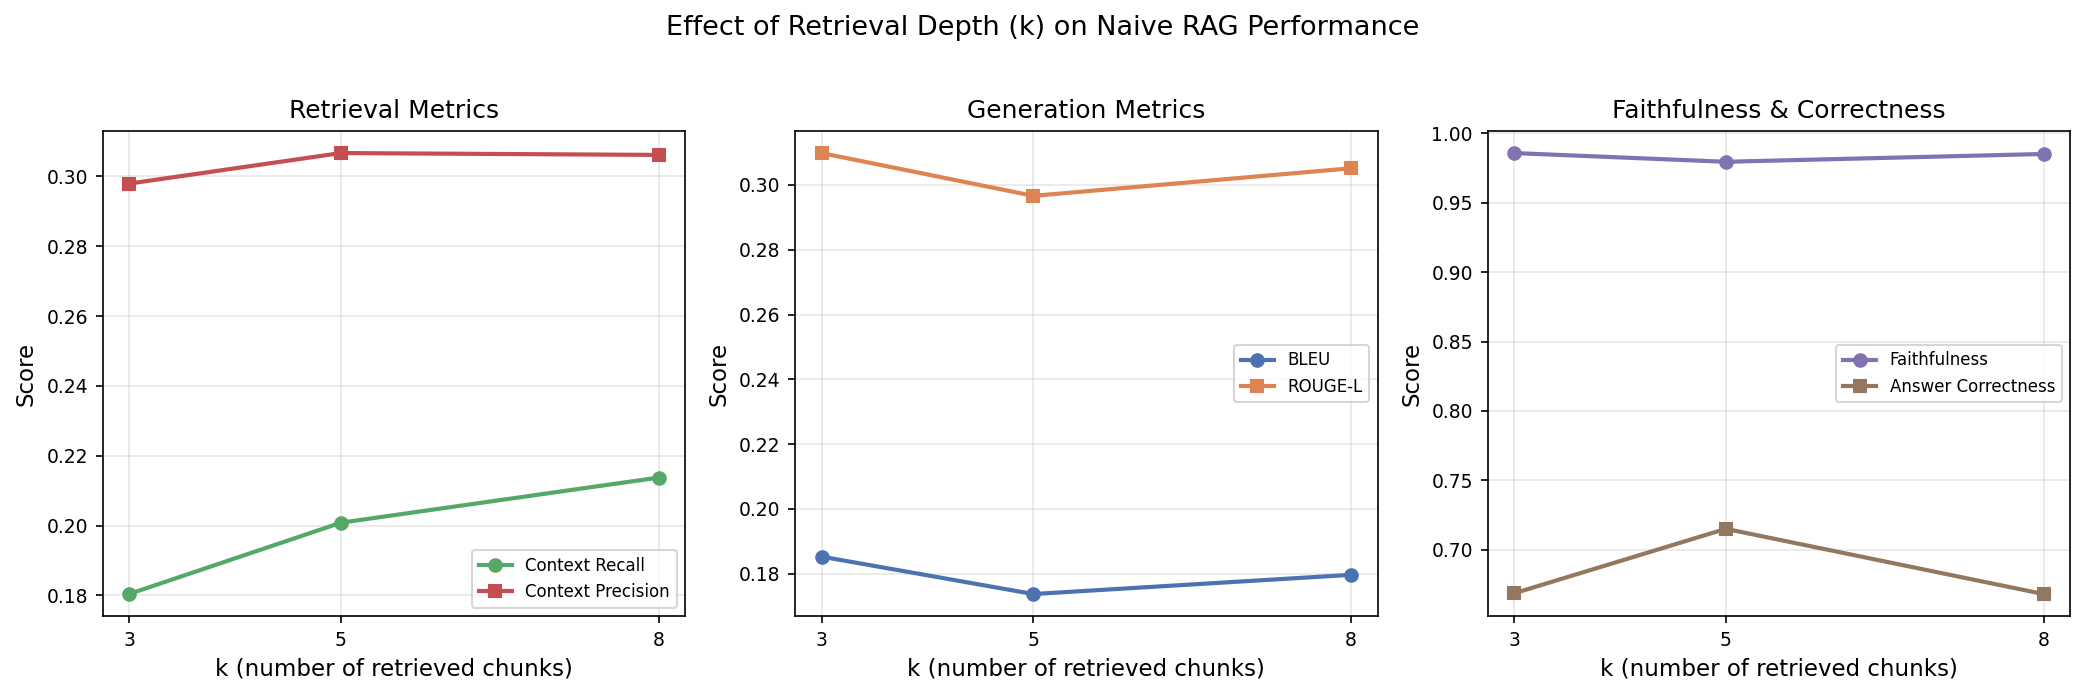

In [23]:
k_values = [3, 5, 8]
k_labels = ["Naive RAG k=3", "Naive RAG k=5", "Naive RAG k=8"]
k_df = metrics_df.loc[k_labels]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Retrieval metrics
axes[0].plot(k_values, k_df["Context Recall (RAGAS)"], 'o-', color="#55A868", label="Context Recall", linewidth=2)
axes[0].plot(k_values, k_df["Context Precision (RAGAS)"], 's-', color="#C44E52", label="Context Precision", linewidth=2)
axes[0].set_xlabel("k (number of retrieved chunks)")
axes[0].set_ylabel("Score")
axes[0].set_title("Retrieval Metrics")
axes[0].set_xticks(k_values)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Generation metrics
axes[1].plot(k_values, k_df["BLEU"], 'o-', color="#4C72B0", label="BLEU", linewidth=2)
axes[1].plot(k_values, k_df["ROUGE-L"], 's-', color="#DD8452", label="ROUGE-L", linewidth=2)
axes[1].set_xlabel("k (number of retrieved chunks)")
axes[1].set_ylabel("Score")
axes[1].set_title("Generation Metrics")
axes[1].set_xticks(k_values)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Safety metrics
axes[2].plot(k_values, k_df["Faithfulness"], 'o-', color="#8172B2", label="Faithfulness", linewidth=2)
if "Answer Correctness" in k_df.columns:
    axes[2].plot(k_values, k_df["Answer Correctness"], 's-', color="#937860", label="Answer Correctness", linewidth=2)
axes[2].set_xlabel("k (number of retrieved chunks)")
axes[2].set_ylabel("Score")
axes[2].set_title("Faithfulness & Correctness")
axes[2].set_xticks(k_values)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("Effect of Retrieval Depth (k) on Naive RAG Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_k_sensitivity.png", bbox_inches="tight")
plt.show()

## Chart 7: Faithfulness Distribution (Box Plot per Architecture)

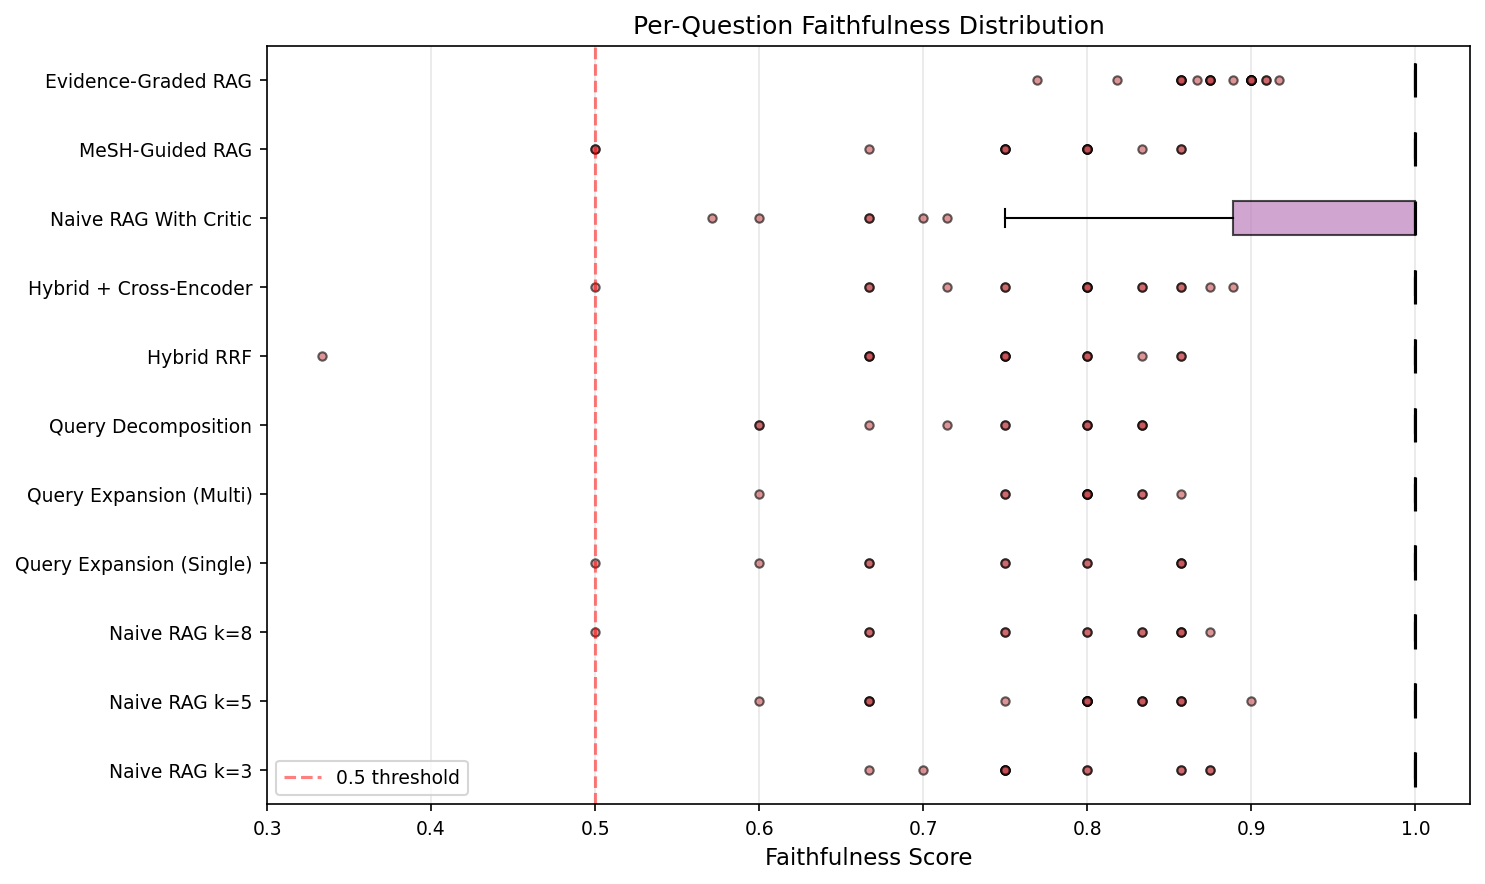

In [24]:
# Load per-question faithfulness scores for each RAG architecture
faith_data = {}
for label, files in ARCHITECTURES.items():
    if "faith" not in files:
        continue
    fpath = DEEPEVAL_DIR / files["faith"]
    if fpath.exists():
        fdf = pd.read_csv(fpath)
        score_col = [c for c in fdf.columns if "faith" in c.lower()][0]
        faith_data[label] = fdf[score_col].values

# Sort by median faithfulness
sorted_archs = sorted(faith_data.keys(), key=lambda a: np.median(faith_data[a]))

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([faith_data[a] for a in sorted_archs], vert=False, patch_artist=True,
                medianprops={"color": "black", "linewidth": 1.5},
                flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "#C44E52", "alpha": 0.6})

colors_box = plt.cm.Set3(np.linspace(0, 1, len(sorted_archs)))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yticklabels(sorted_archs)
ax.set_xlabel("Faithfulness Score")
ax.set_title("Per-Question Faithfulness Distribution")
ax.grid(axis="x", alpha=0.3)
ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="0.5 threshold")
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_faithfulness_boxplot.png", bbox_inches="tight")
plt.show()

## Chart 8: Comprehensive Summary Heatmap

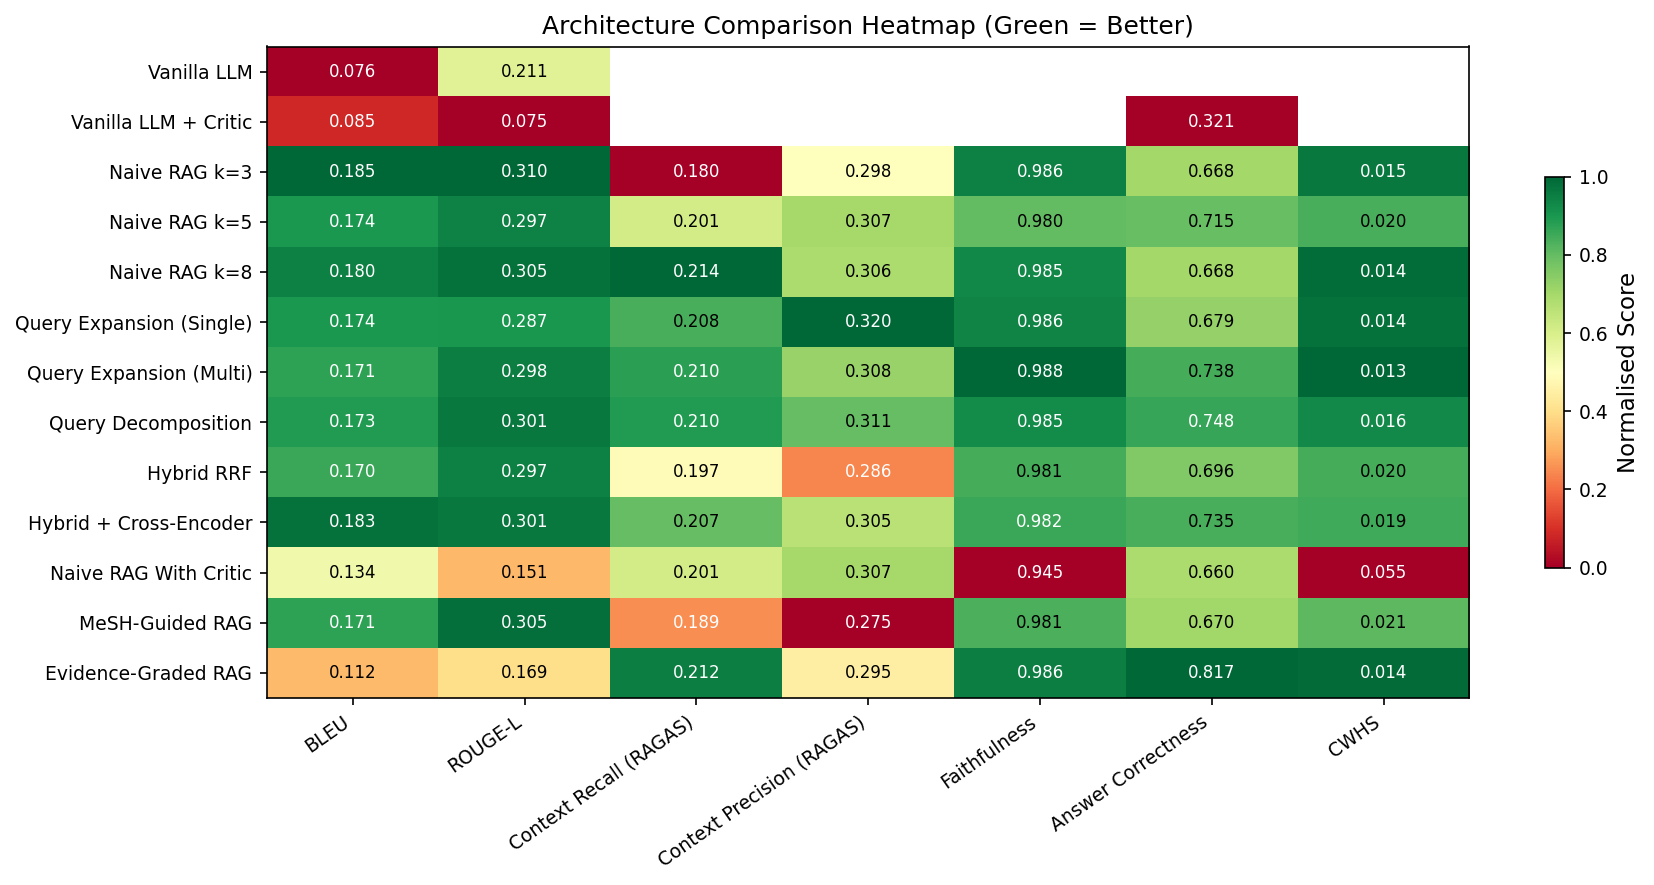

In [25]:
heatmap_cols = ["BLEU", "ROUGE-L", "Context Recall (RAGAS)", "Context Precision (RAGAS)",
                "Faithfulness", "Answer Correctness", "CWHS"]
heatmap_df = metrics_df[[c for c in heatmap_cols if c in metrics_df.columns]].dropna(how="all")
heatmap_df = heatmap_df.dropna(axis=0, how="all")

# Normalise columns to [0, 1] for colour mapping
norm_df = heatmap_df.copy()
for col in norm_df.columns:
    cmin, cmax = norm_df[col].min(), norm_df[col].max()
    if cmax > cmin:
        norm_df[col] = (norm_df[col] - cmin) / (cmax - cmin)
    else:
        norm_df[col] = 0.5

# For CWHS, invert (lower is better)
if "CWHS" in norm_df.columns:
    norm_df["CWHS"] = 1 - norm_df["CWHS"]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(norm_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(norm_df.columns)))
ax.set_xticklabels(norm_df.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(norm_df)))
ax.set_yticklabels(norm_df.index)

# Annotate with actual values
for i in range(len(norm_df)):
    for j in range(len(norm_df.columns)):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            text_color = "white" if norm_df.iloc[i, j] < 0.3 or norm_df.iloc[i, j] > 0.85 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8, color=text_color)

ax.set_title("Architecture Comparison Heatmap (Green = Better)")
plt.colorbar(im, ax=ax, shrink=0.6, label="Normalised Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_heatmap_summary.png", bbox_inches="tight")
plt.show()

## Chart 9: Critic Effect — Before vs After Adding Critic

Shows the impact of adding a critic-revision loop to both Vanilla LLM and Naive RAG k=5.

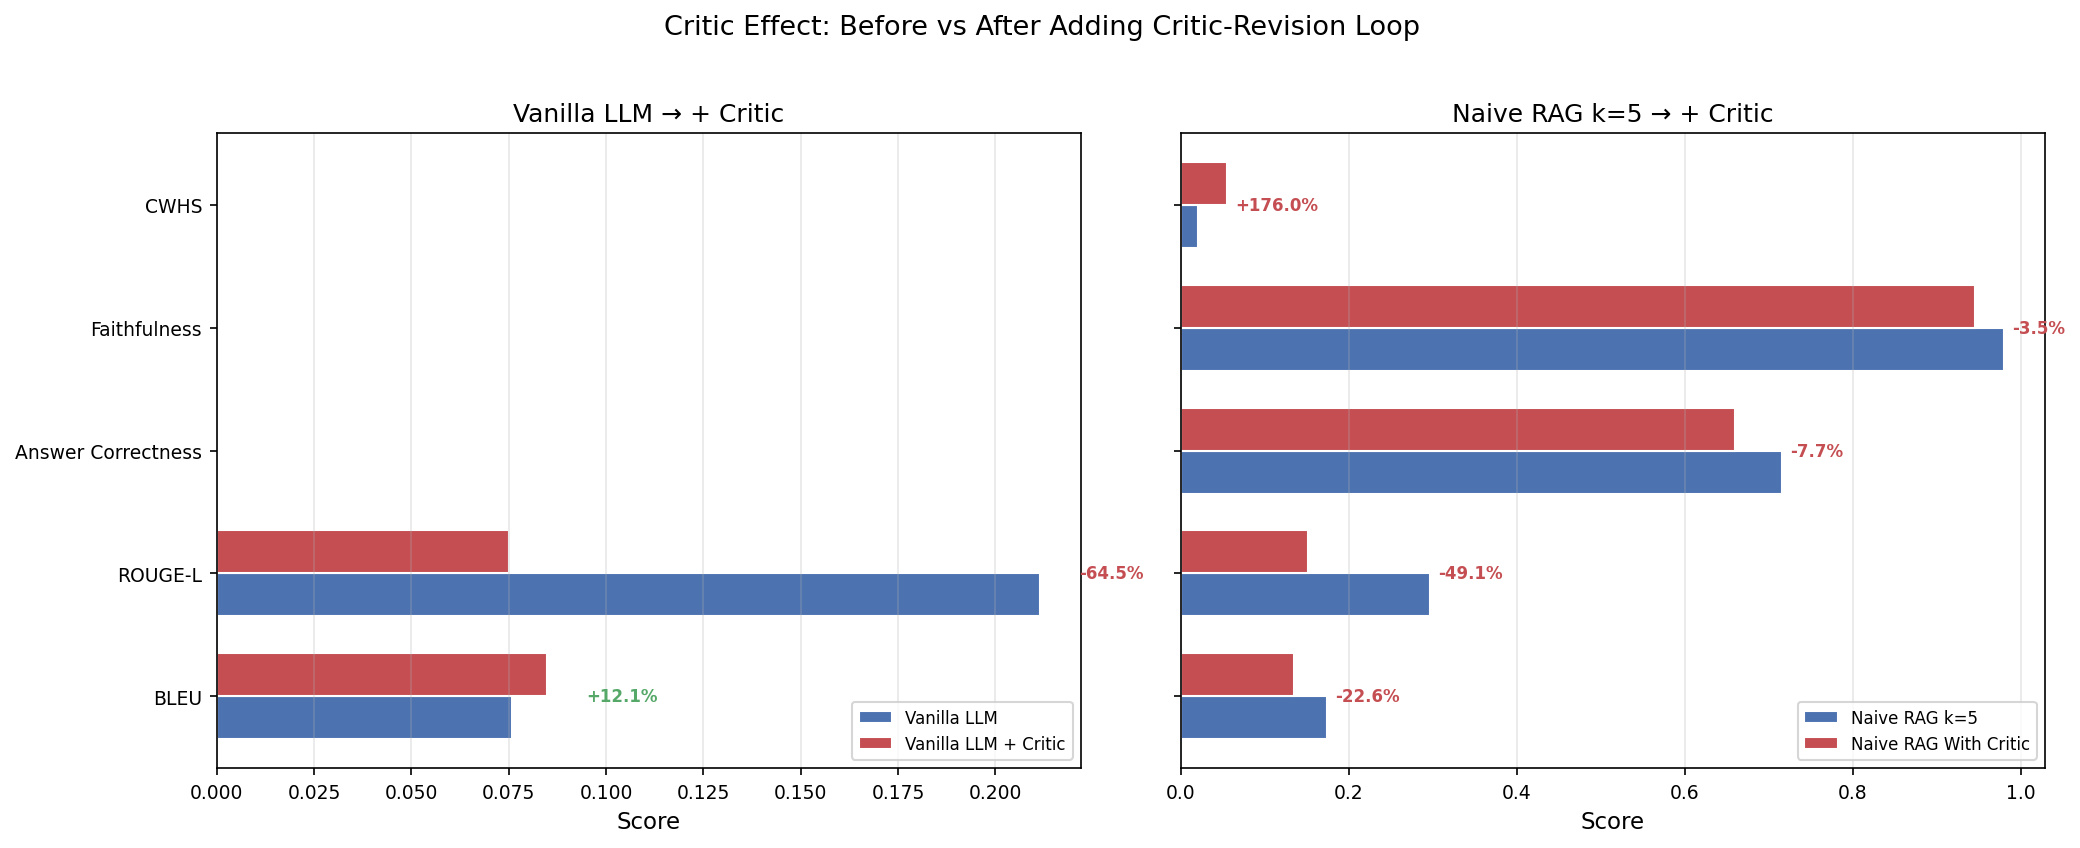

In [37]:
critic_pairs = {
    "Vanilla LLM": "Vanilla LLM + Critic",
    "Naive RAG k=5": "Naive RAG With Critic",
}
critic_metrics = ["BLEU", "ROUGE-L", "Answer Correctness", "Faithfulness", "CWHS"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax_idx, (base, critic) in enumerate(critic_pairs.items()):
    available = [m for m in critic_metrics
                 if m in metrics_df.columns
                 and base in metrics_df.index
                 and critic in metrics_df.index
                 and pd.notna(metrics_df.loc[base, m])
                 and pd.notna(metrics_df.loc[critic, m])]

    base_vals = [metrics_df.loc[base, m] for m in available]
    critic_vals = [metrics_df.loc[critic, m] for m in available]

    y = np.arange(len(available))
    bar_h = 0.35

    axes[ax_idx].barh(y - bar_h/2, base_vals, bar_h, label=base, color="#4C72B0", edgecolor="white")
    axes[ax_idx].barh(y + bar_h/2, critic_vals, bar_h, label=critic, color="#C44E52", edgecolor="white")

    axes[ax_idx].set_yticks(y)
    axes[ax_idx].set_yticklabels(available)
    axes[ax_idx].set_xlabel("Score")
    axes[ax_idx].set_title(f"{base} → + Critic")
    axes[ax_idx].legend(fontsize=8, loc="lower right")
    axes[ax_idx].grid(axis="x", alpha=0.3)

    for i, (bv, cv) in enumerate(zip(base_vals, critic_vals)):
        pct = ((cv - bv) / bv) * 100 if bv != 0 else 0
        color = "#55A868" if pct > 0 else "#C44E52"
        if available[i] == "CWHS":
            color = "#55A868" if pct < 0 else "#C44E52"
        axes[ax_idx].text(max(bv, cv) + 0.01, i, f"{pct:+.1f}%", va="center", fontsize=8, color=color, fontweight="bold")

plt.suptitle("Critic Effect: Before vs After Adding Critic-Revision Loop", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_critic_effect.png", bbox_inches="tight")
plt.show()

## Chart 10: Query Expansion Family — Single vs Multi

In [39]:
metrics_df

,BLEU,ROUGE-L,Context Recall (RAGAS),Context Precision (RAGAS),Mean Latency (s),Mean Tokens,Answer Correctness,Faithfulness,CWHS,Δ (CWHS − Unweighted)
Architecture,,,,,,,,,,
Vanilla LLM,0.075741,0.211349,NaN,NaN,0.517527,173.525000,NaN,NaN,NaN,NaN
Vanilla LLM + Critic,0.084940,0.075124,NaN,NaN,7.303272,2425.205128,0.3210,NaN,NaN,NaN
Naive RAG k=3,0.185288,0.309834,0.180417,0.297917,NaN,NaN,0.6685,0.985905,0.0148,0.0007
Naive RAG k=5,0.173740,0.296624,0.200833,0.306667,NaN,NaN,0.7150,0.979607,0.0200,-0.0003
Naive RAG k=8,0.179665,0.305132,0.213750,0.306131,NaN,NaN,0.6680,0.985232,0.0137,-0.0011
Query Expansion (Single),0.174142,0.286659,0.208333,0.320167,6.001575,1852.850000,0.6795,0.985524,0.0141,-0.0003
Query Expansion (Multi),0.171219,0.297973,0.209583,0.307750,5.432509,2049.320000,0.7385,0.988119,0.0132,0.0013
Query Decomposition,0.172887,0.300827,0.210000,0.311083,3.757946,2089.360000,0.7475,0.984905,0.0163,0.0012
Hybrid RRF,0.169784,0.297043,0.196667,0.286111,4.240257,1804.780000,0.6955,0.981405,0.0198,0.0013


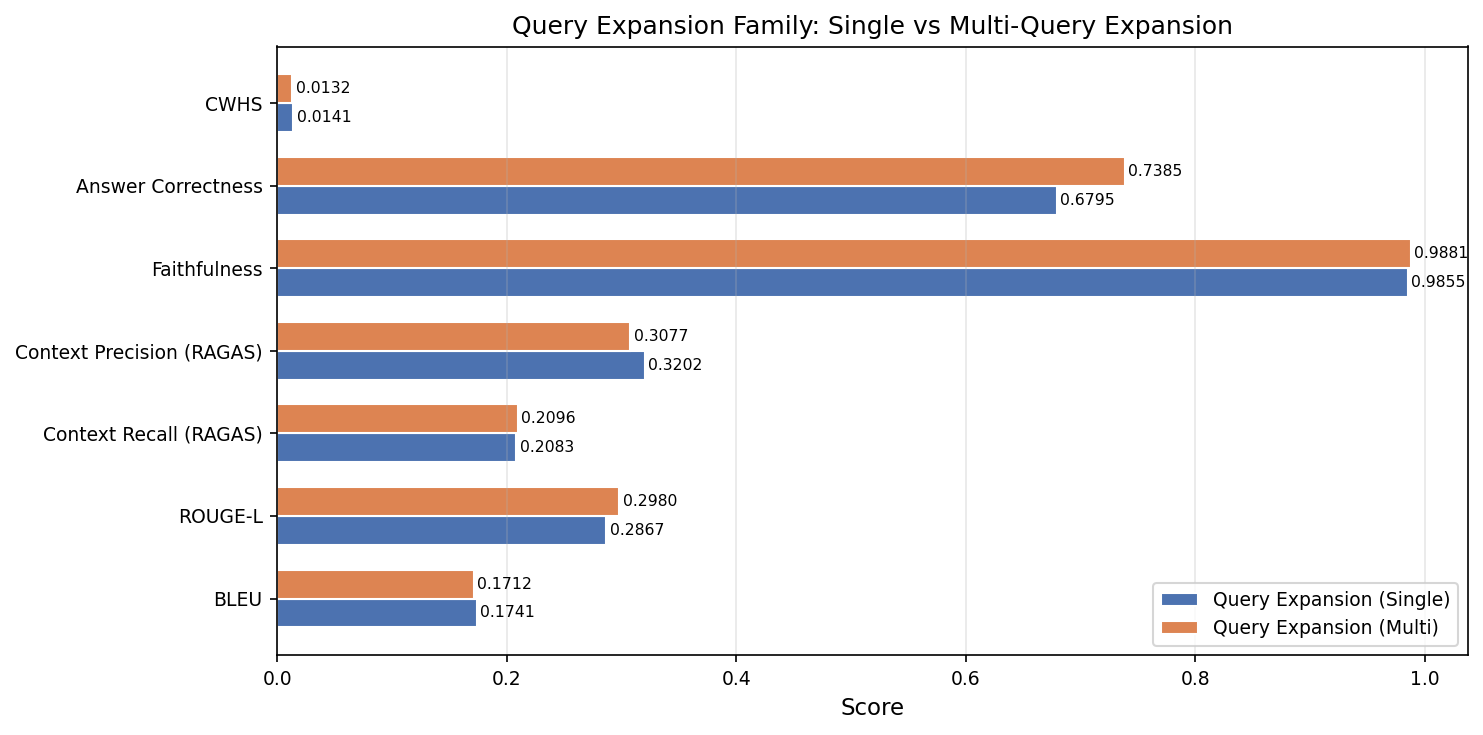

In [40]:
family_metrics = ["BLEU", "ROUGE-L", "Context Recall (RAGAS)", "Context Precision (RAGAS)",
                  "Faithfulness", "Answer Correctness", "CWHS"]

qe_archs = ["Query Expansion (Single)", "Query Expansion (Multi)"]
qe_df = metrics_df.loc[qe_archs, [m for m in family_metrics if m in metrics_df.columns]].dropna(axis=1, how="any")

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(qe_df.columns))
bar_h = 0.35

bars1 = ax.barh(y - bar_h/2, qe_df.iloc[0].values, bar_h, label=qe_archs[0], color="#4C72B0", edgecolor="white")
bars2 = ax.barh(y + bar_h/2, qe_df.iloc[1].values, bar_h, label=qe_archs[1], color="#DD8452", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(qe_df.columns)
ax.set_xlabel("Score")
ax.set_title("Query Expansion Family: Single vs Multi-Query Expansion")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_query_expansion_family.png", bbox_inches="tight")
plt.show()

## Chart 11: Hybrid RAG Family — RRF vs Cross-Encoder

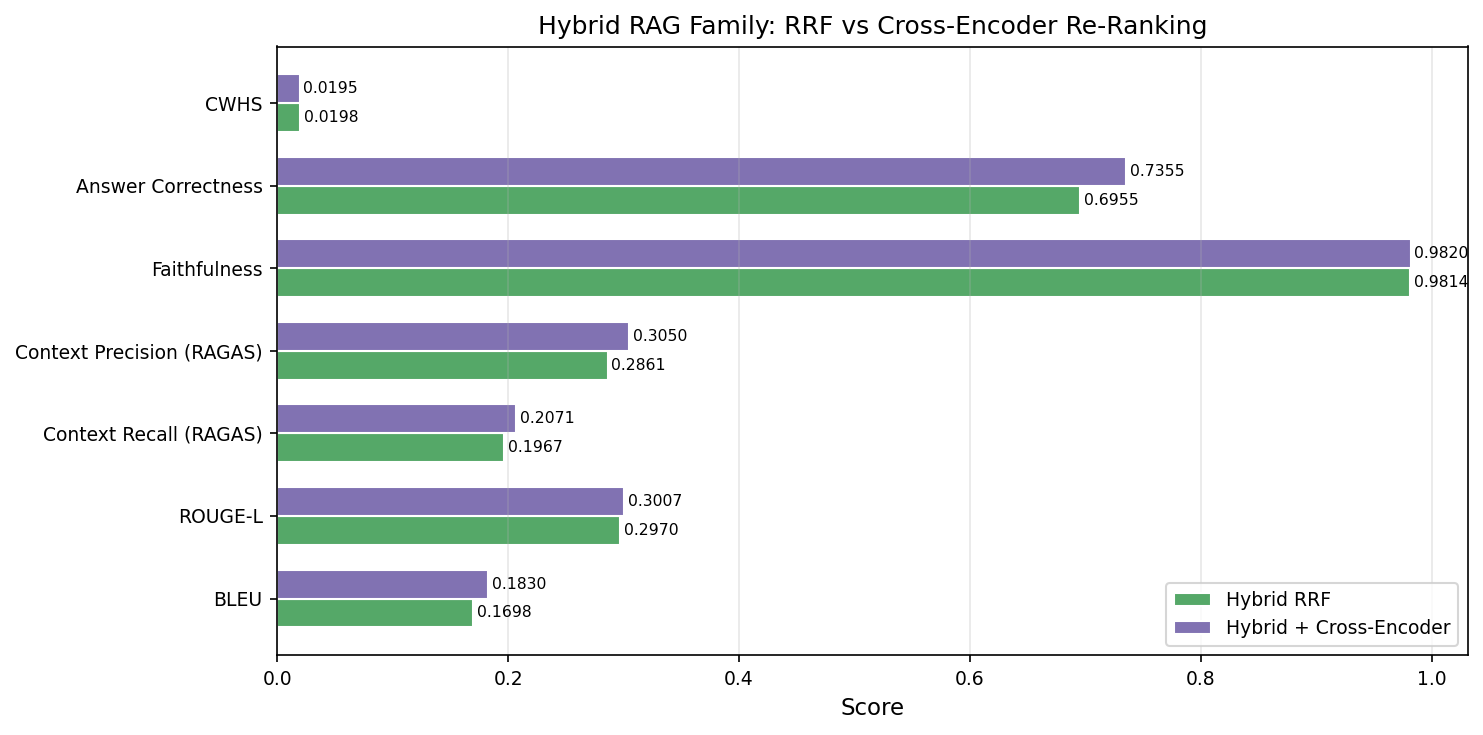

In [41]:
hybrid_archs = ["Hybrid RRF", "Hybrid + Cross-Encoder"]
hybrid_df = metrics_df.loc[hybrid_archs, [m for m in family_metrics if m in metrics_df.columns]].dropna(axis=1, how="any")

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(hybrid_df.columns))
bar_h = 0.35

bars1 = ax.barh(y - bar_h/2, hybrid_df.iloc[0].values, bar_h, label=hybrid_archs[0], color="#55A868", edgecolor="white")
bars2 = ax.barh(y + bar_h/2, hybrid_df.iloc[1].values, bar_h, label=hybrid_archs[1], color="#8172B2", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(hybrid_df.columns)
ax.set_xlabel("Score")
ax.set_title("Hybrid RAG Family: RRF vs Cross-Encoder Re-Ranking")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_hybrid_family.png", bbox_inches="tight")
plt.show()

## Chart 12: Evidence-Graded RAG — Routing Distribution & Per-Route Answer Correctness

Shows the LLM router's strategy selection distribution and whether routing strategy correlates with answer quality.

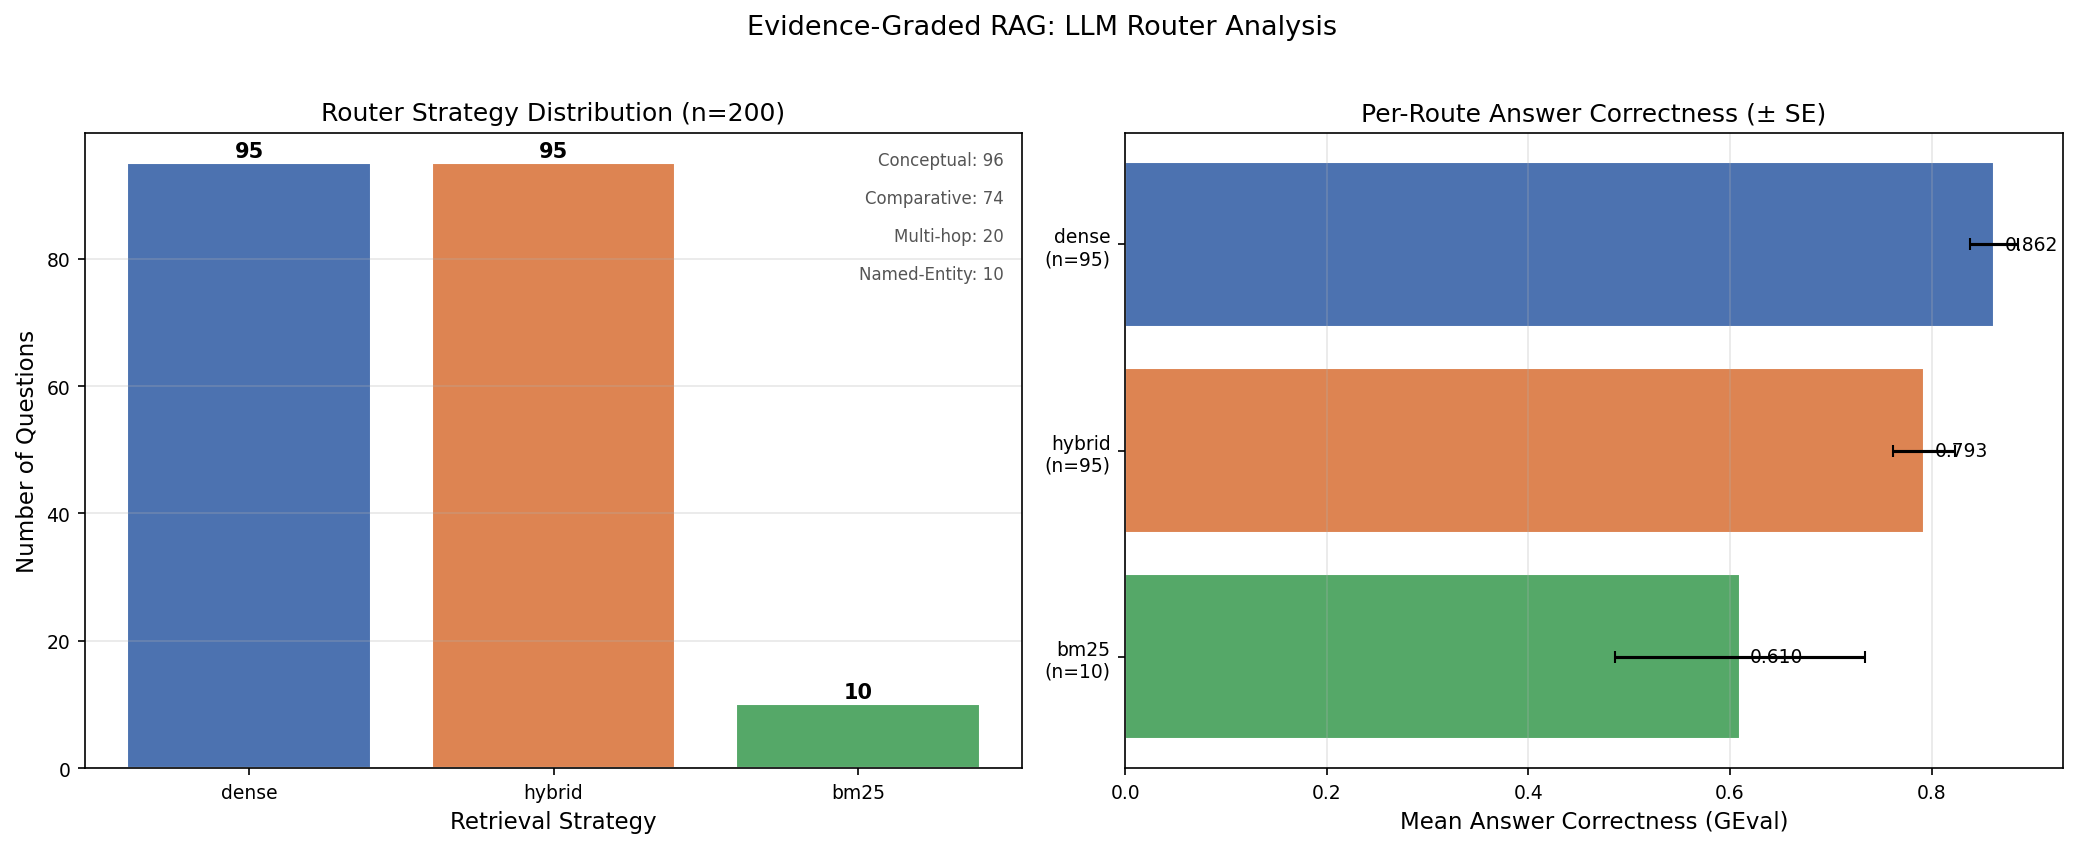

In [42]:
eg_eval = pd.read_csv(EVAL_DIR / "evidence_graded_rag_minilm_chroma_20260516_164252.csv")
eg_corr = pd.read_csv(DEEPEVAL_DIR / "evidence_graded_rag_minilm_answer_correctness_20260516_164252.csv")

corr_col = [c for c in eg_corr.columns if "correct" in c.lower()][0]
eg_merged = eg_eval.merge(eg_corr[["question_idx", corr_col]], on="question_idx", how="left")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Routing distribution (bar chart by route_strategy and route_type)
strategy_counts = eg_eval["route_strategy"].value_counts()
strategy_colors = {"dense": "#4C72B0", "hybrid": "#DD8452", "bm25": "#55A868"}
bars = ax1.bar(strategy_counts.index, strategy_counts.values,
               color=[strategy_colors.get(s, "#999") for s in strategy_counts.index], edgecolor="white")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(bar.get_height())}", ha="center", fontsize=10, fontweight="bold")

type_counts = eg_eval["route_type"].value_counts()
for i, (rtype, count) in enumerate(type_counts.items()):
    ax1.annotate(f"{rtype}: {count}", xy=(0.98, 0.95 - i*0.06), xycoords="axes fraction",
                 fontsize=8, ha="right", color="#555")

ax1.set_xlabel("Retrieval Strategy")
ax1.set_ylabel("Number of Questions")
ax1.set_title("Router Strategy Distribution (n=200)")
ax1.grid(axis="y", alpha=0.3)

# Right: Per-route mean answer correctness
route_corr = eg_merged.groupby("route_strategy")[corr_col].agg(["mean", "std", "count"])
route_corr = route_corr.sort_values("mean", ascending=True)

y = np.arange(len(route_corr))
bars2 = ax2.barh(y, route_corr["mean"], color=[strategy_colors.get(s, "#999") for s in route_corr.index],
                 edgecolor="white", xerr=route_corr["std"] / np.sqrt(route_corr["count"]), capsize=3)
ax2.set_yticks(y)
ax2.set_yticklabels([f"{s}\n(n={int(route_corr.loc[s, 'count'])})" for s in route_corr.index])
ax2.set_xlabel("Mean Answer Correctness (GEval)")
ax2.set_title("Per-Route Answer Correctness (± SE)")
ax2.grid(axis="x", alpha=0.3)

for bar, val in zip(bars2, route_corr["mean"]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Evidence-Graded RAG: LLM Router Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_evidence_graded_routing.png", bbox_inches="tight")
plt.show()

## Chart 13: Per-Question Answer Correctness Distribution (Violin Plot)

Shows the full distribution of answer correctness scores — not just means — to reveal whether improvements are uniform or driven by outliers.

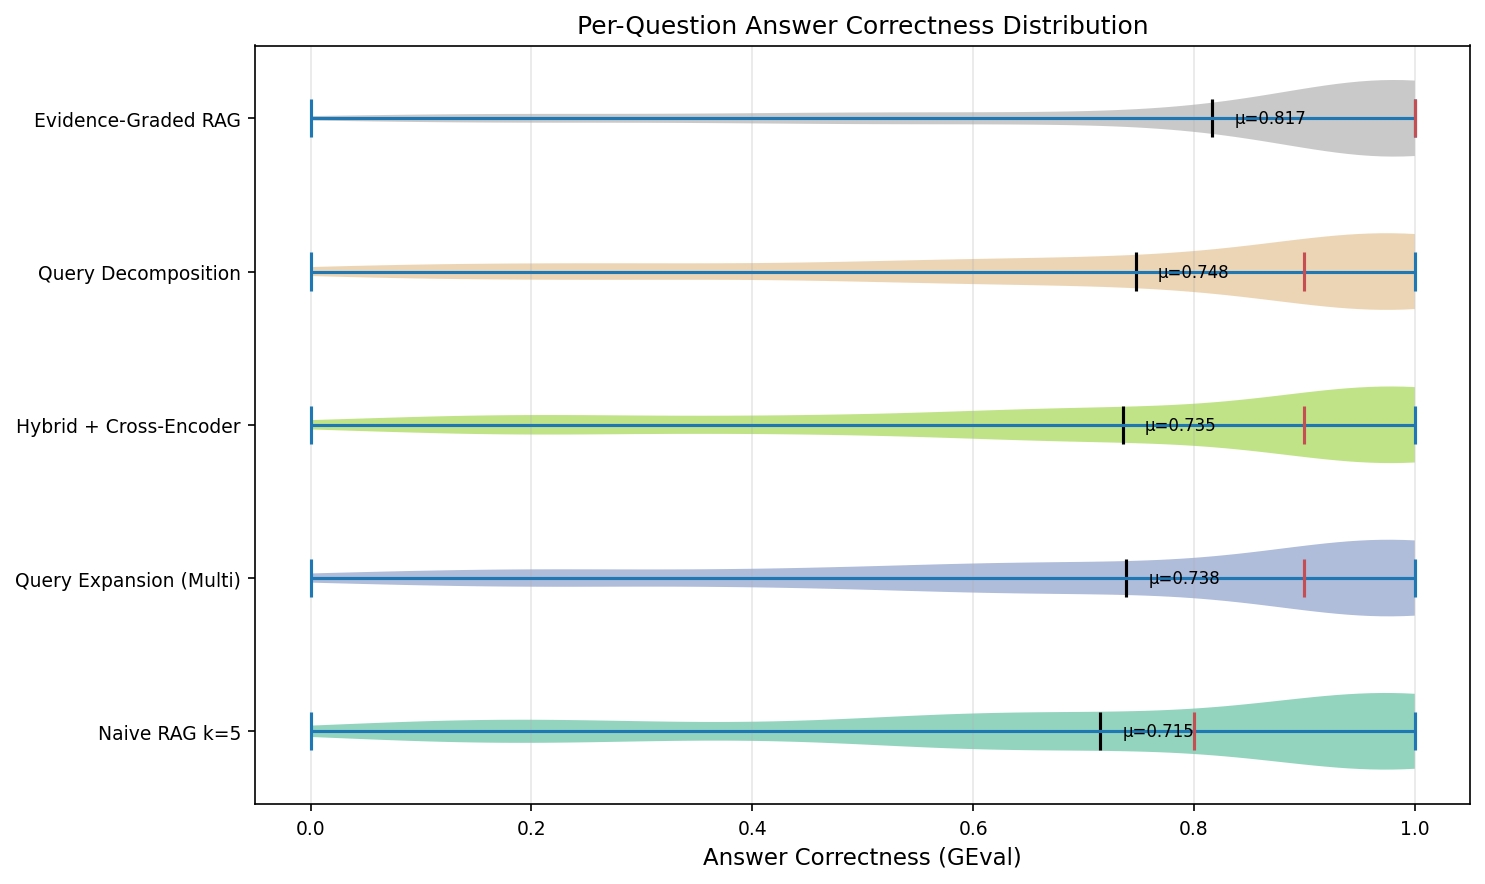

In [43]:
violin_archs = ["Naive RAG k=5", "Query Expansion (Multi)", "Hybrid + Cross-Encoder",
                "Query Decomposition", "Evidence-Graded RAG", "Naive RAG + Critic"]

corr_data = {}
for label in violin_archs:
    if label in ARCHITECTURES and "corr" in ARCHITECTURES[label]:
        cpath = DEEPEVAL_DIR / ARCHITECTURES[label]["corr"]
        if cpath.exists():
            cdf = pd.read_csv(cpath)
            score_col = [c for c in cdf.columns if "correct" in c.lower()][0]
            corr_data[label] = cdf[score_col].dropna().values

sorted_labels = sorted(corr_data.keys(), key=lambda a: np.median(corr_data[a]))

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot([corr_data[a] for a in sorted_labels], vert=False, showmeans=True, showmedians=True)

colors_violin = plt.cm.Set2(np.linspace(0, 1, len(sorted_labels)))
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.7)
parts["cmeans"].set_color("black")
parts["cmedians"].set_color("#C44E52")

ax.set_yticks(range(1, len(sorted_labels) + 1))
ax.set_yticklabels(sorted_labels)
ax.set_xlabel("Answer Correctness (GEval)")
ax.set_title("Per-Question Answer Correctness Distribution")
ax.grid(axis="x", alpha=0.3)

for i, label in enumerate(sorted_labels):
    mean_val = np.mean(corr_data[label])
    ax.text(mean_val + 0.02, i + 1, f"μ={mean_val:.3f}", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_correctness_violin.png", bbox_inches="tight")
plt.show()

## Chart 14: Latency Distribution (Box Plot)

Shows per-question latency distributions including variance and tail latency for all architectures with timing data.

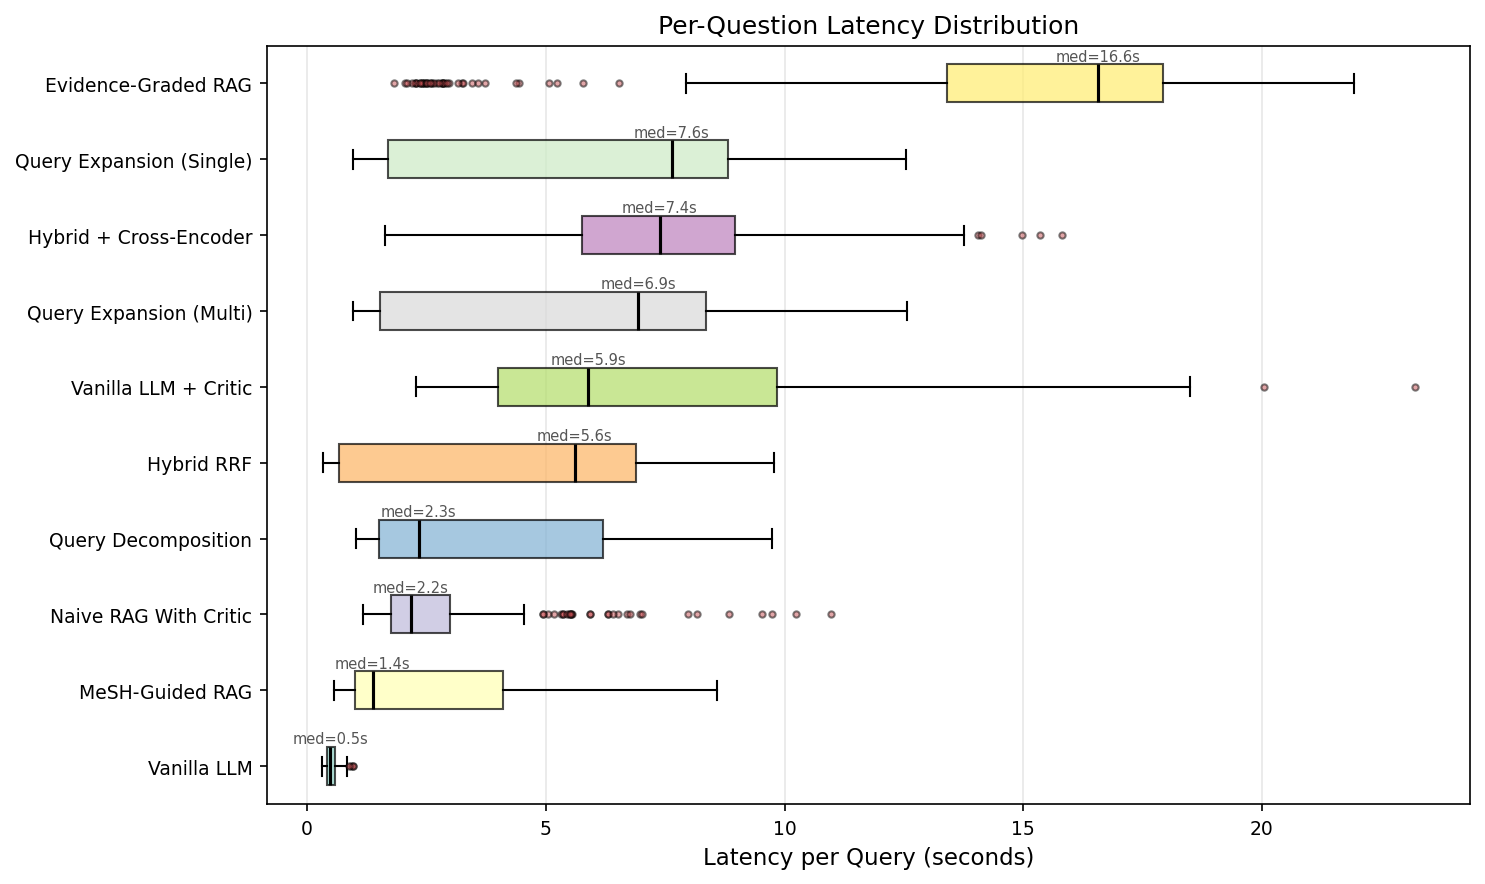

In [44]:
latency_data = {}
for label, files in ARCHITECTURES.items():
    eval_path = EVAL_DIR / files["eval"]
    if eval_path.exists():
        edf = pd.read_csv(eval_path)
        if "total_time" in edf.columns:
            vals = edf["total_time"].dropna().values
            if len(vals) > 0:
                latency_data[label] = vals

sorted_lat = sorted(latency_data.keys(), key=lambda a: np.median(latency_data[a]))

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([latency_data[a] for a in sorted_lat], vert=False, patch_artist=True,
                medianprops={"color": "black", "linewidth": 1.5},
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#C44E52", "alpha": 0.5})

colors_box = plt.cm.Set3(np.linspace(0, 1, len(sorted_lat)))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yticklabels(sorted_lat)
ax.set_xlabel("Latency per Query (seconds)")
ax.set_title("Per-Question Latency Distribution")
ax.grid(axis="x", alpha=0.3)

for i, label in enumerate(sorted_lat):
    med = np.median(latency_data[label])
    ax.text(med, i + 1.3, f"med={med:.1f}s", fontsize=7, ha="center", color="#555")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_latency_boxplot.png", bbox_inches="tight")
plt.show()

## Chart 15: Multi-Agent Family — Evidence-Graded vs MeSH-Guided

Direct comparison of the two multi-agent approaches: shared metrics and severity-stratified hallucination profiles.

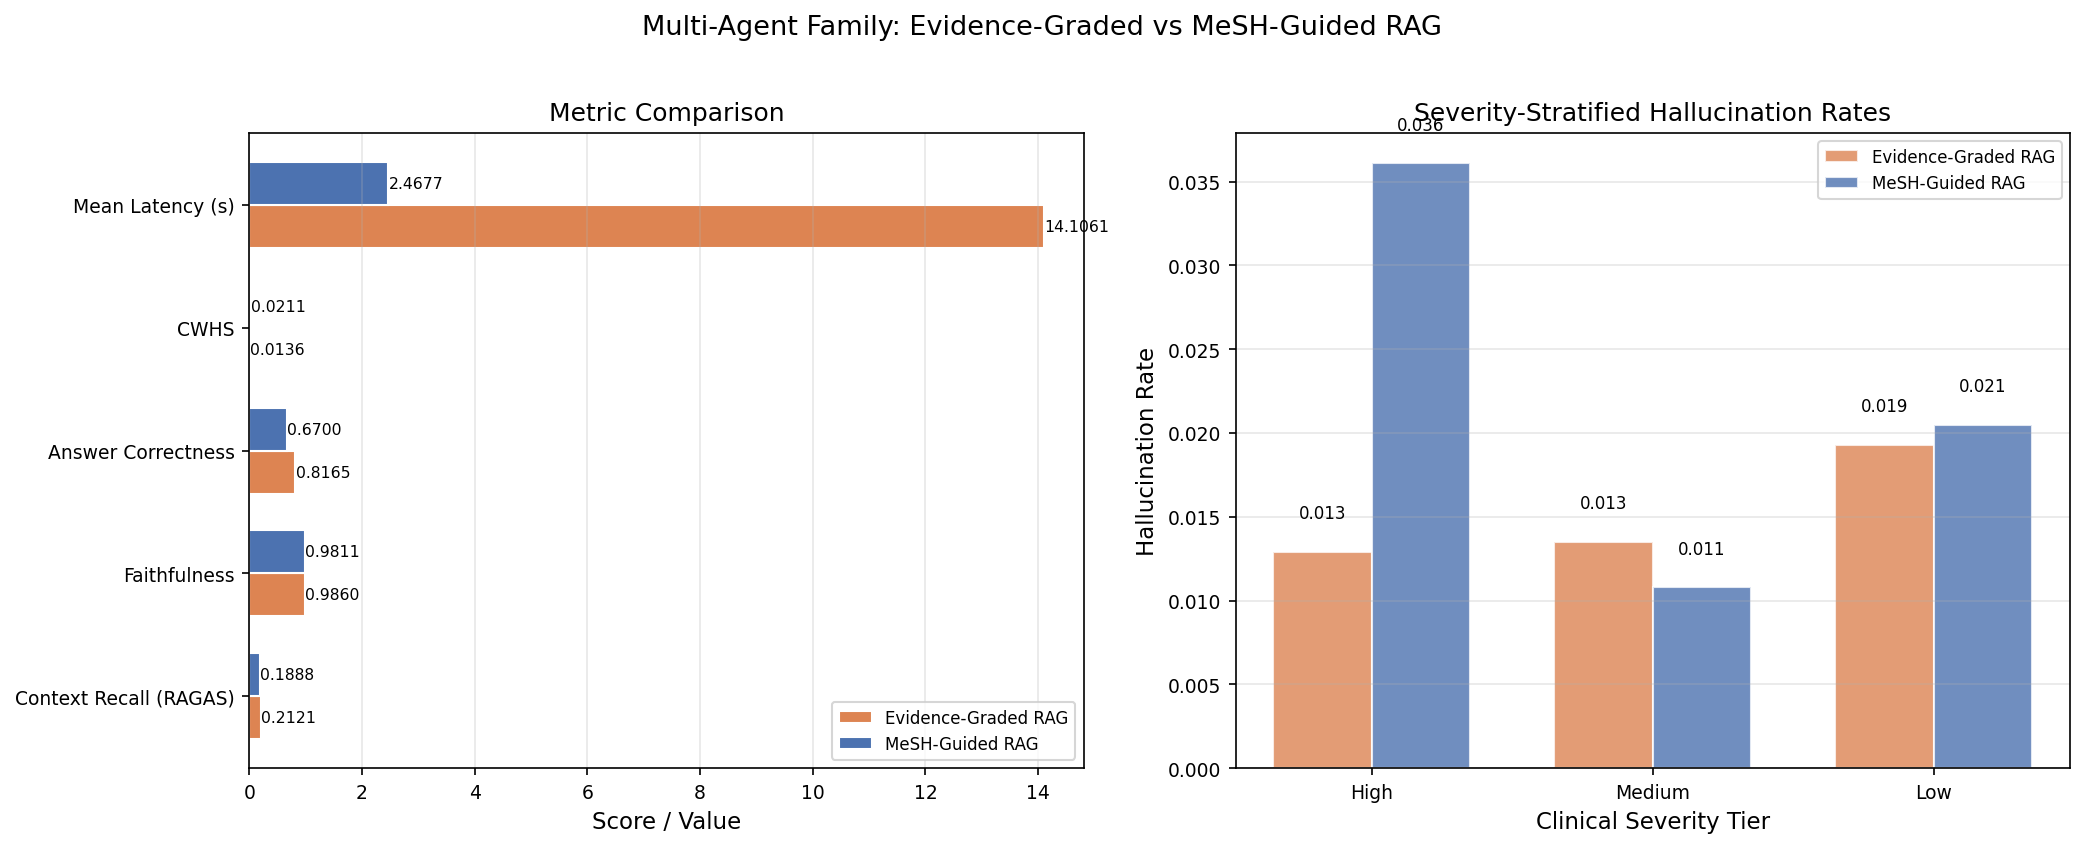

In [45]:
ma_archs = ["Evidence-Graded RAG", "MeSH-Guided RAG"]
ma_metrics = ["Context Recall (RAGAS)", "Faithfulness", "Answer Correctness", "CWHS", "Mean Latency (s)"]
ma_df = metrics_df.loc[ma_archs, [m for m in ma_metrics if m in metrics_df.columns]].dropna(axis=1, how="any")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Shared metrics comparison
y = np.arange(len(ma_df.columns))
bar_h = 0.35
bars1 = ax1.barh(y - bar_h/2, ma_df.iloc[0].values, bar_h, label=ma_archs[0], color="#DD8452", edgecolor="white")
bars2 = ax1.barh(y + bar_h/2, ma_df.iloc[1].values, bar_h, label=ma_archs[1], color="#4C72B0", edgecolor="white")

ax1.set_yticks(y)
ax1.set_yticklabels(ma_df.columns)
ax1.set_xlabel("Score / Value")
ax1.set_title("Metric Comparison")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)
for bar in bars2:
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=7.5)

# Right: Severity-stratified hallucination comparison
bd_df = pd.read_csv(FIGURES_DIR / "cwhs_breakdown_by_severity.csv").set_index("Architecture")
sev_tiers = ["High Hal. Rate", "Medium Hal. Rate", "Low Hal. Rate"]
sev_labels = ["High", "Medium", "Low"]
sev_colors = ["#C44E52", "#DD8452", "#55A868"]

x = np.arange(len(sev_tiers))
bar_w = 0.35
for i, arch in enumerate(ma_archs):
    if arch in bd_df.index:
        vals = [bd_df.loc[arch, t] for t in sev_tiers]
        offset = -bar_w/2 if i == 0 else bar_w/2
        bars = ax2.bar(x + offset, vals, bar_w, label=arch,
                       color=["#DD8452", "#DD8452", "#DD8452"] if i == 0 else ["#4C72B0", "#4C72B0", "#4C72B0"],
                       edgecolor="white", alpha=0.8)
        for bar in bars:
            if bar.get_height() > 0.001:
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                         f"{bar.get_height():.3f}", ha="center", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(sev_labels)
ax2.set_xlabel("Clinical Severity Tier")
ax2.set_ylabel("Hallucination Rate")
ax2.set_title("Severity-Stratified Hallucination Rates")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Multi-Agent Family: Evidence-Graded vs MeSH-Guided RAG", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_multi_agent_family.png", bbox_inches="tight")
plt.show()

## Chart 16: CWHS and Delta — Clinical Safety Comparison

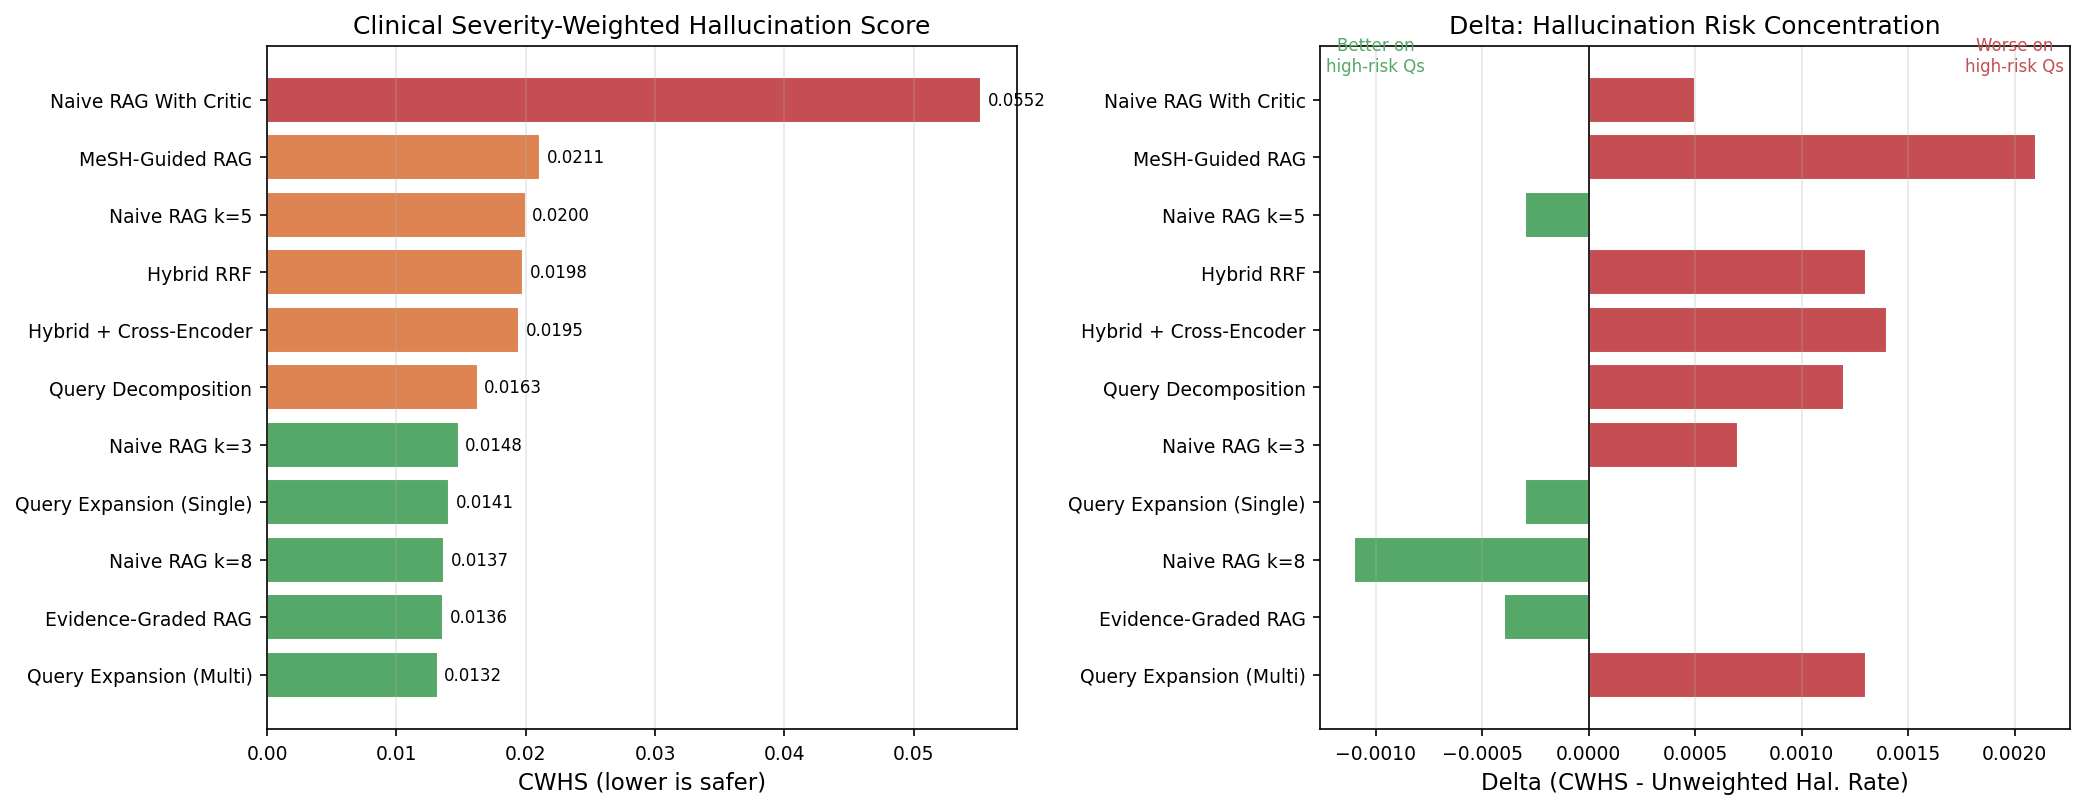

In [46]:
cwhs_chart_df = metrics_df[["CWHS", "Δ (CWHS − Unweighted)"]].dropna().sort_values("CWHS", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: CWHS bar chart
colors_cwhs = ["#C44E52" if v > 0.025 else "#DD8452" if v > 0.015 else "#55A868" for v in cwhs_chart_df["CWHS"]]
bars = ax1.barh(range(len(cwhs_chart_df)), cwhs_chart_df["CWHS"], color=colors_cwhs, edgecolor="white")
ax1.set_yticks(range(len(cwhs_chart_df)))
ax1.set_yticklabels(cwhs_chart_df.index)
ax1.set_xlabel("CWHS (lower is safer)")
ax1.set_title("Clinical Severity-Weighted Hallucination Score")
ax1.grid(axis="x", alpha=0.3)
for bar in bars:
    ax1.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=8)

# Right: Delta diverging bar chart
delta_vals = cwhs_chart_df["Δ (CWHS − Unweighted)"]
colors_delta = ["#C44E52" if v > 0 else "#55A868" for v in delta_vals]
ax2.barh(range(len(cwhs_chart_df)), delta_vals, color=colors_delta, edgecolor="white")
ax2.set_yticks(range(len(cwhs_chart_df)))
ax2.set_yticklabels(cwhs_chart_df.index)
ax2.set_xlabel("Delta (CWHS - Unweighted Hal. Rate)")
ax2.set_title("Delta: Hallucination Risk Concentration")
ax2.axvline(x=0, color="black", linewidth=0.8, linestyle="-")
ax2.grid(axis="x", alpha=0.3)
ax2.annotate("Worse on\nhigh-risk Qs", xy=(0.002, len(cwhs_chart_df)-0.5), fontsize=8, color="#C44E52", ha="center")
ax2.annotate("Better on\nhigh-risk Qs", xy=(-0.001, len(cwhs_chart_df)-0.5), fontsize=8, color="#55A868", ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_cwhs_delta.png", bbox_inches="tight")
plt.show()

## Chart 17: Severity-Stratified Hallucination Rates (Grouped Bar)

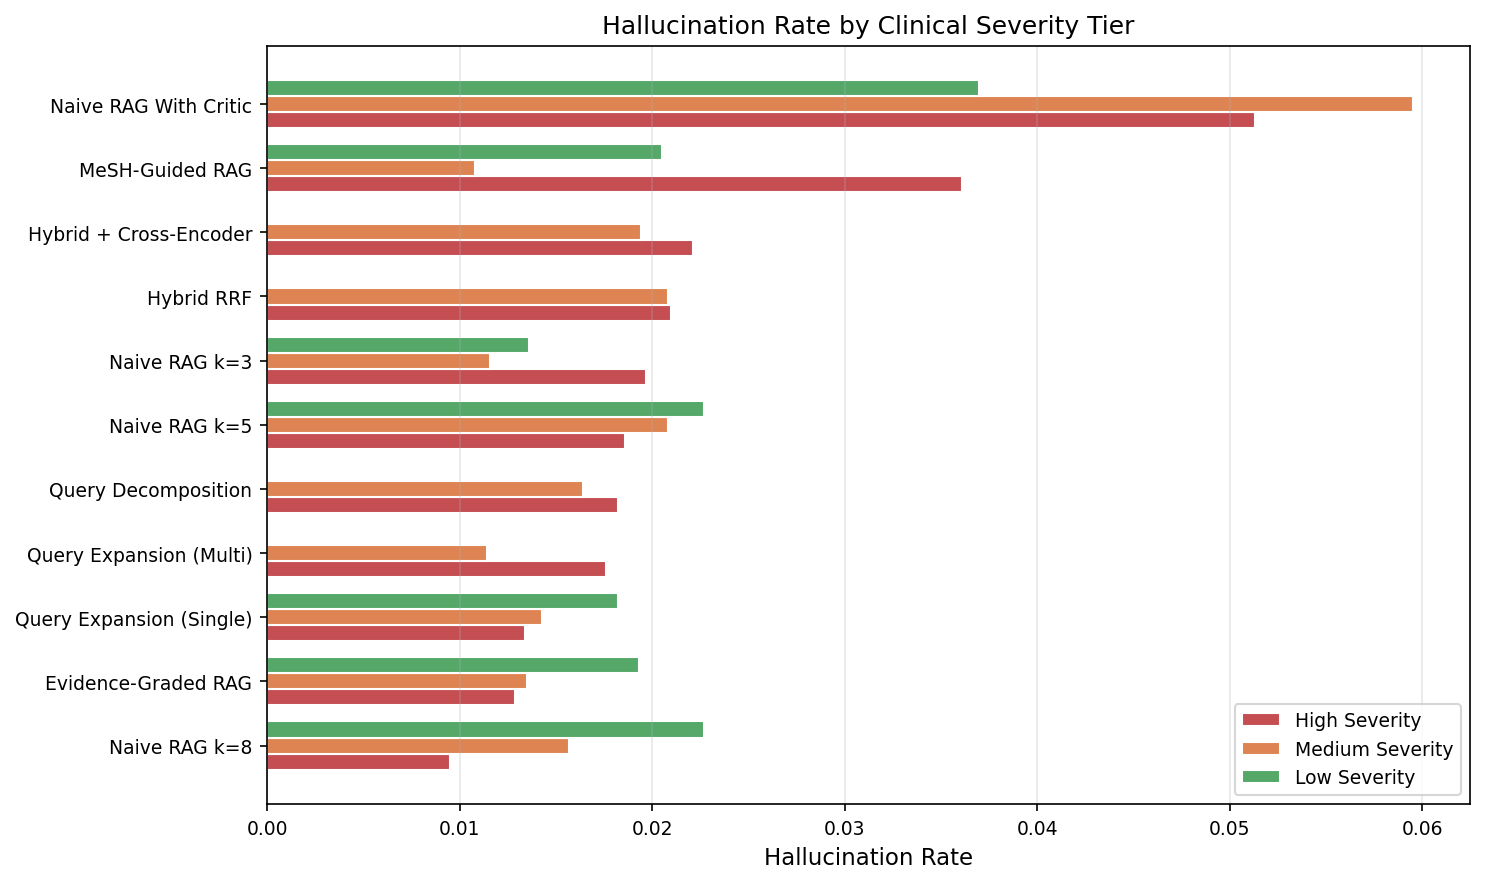

In [47]:
breakdown_path = FIGURES_DIR / "cwhs_breakdown_by_severity.csv"
bd_df = pd.read_csv(breakdown_path).set_index("Architecture")

bd_plot = bd_df[["High Hal. Rate", "Medium Hal. Rate", "Low Hal. Rate"]].sort_values("High Hal. Rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(bd_plot))
bar_height = 0.25

ax.barh(y - bar_height, bd_plot["High Hal. Rate"], bar_height, label="High Severity", color="#C44E52", edgecolor="white")
ax.barh(y, bd_plot["Medium Hal. Rate"], bar_height, label="Medium Severity", color="#DD8452", edgecolor="white")
ax.barh(y + bar_height, bd_plot["Low Hal. Rate"], bar_height, label="Low Severity", color="#55A868", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(bd_plot.index)
ax.set_xlabel("Hallucination Rate")
ax.set_title("Hallucination Rate by Clinical Severity Tier")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_severity_breakdown.png", bbox_inches="tight")
plt.show()

## Chart 18: Clinical Safety Score (CSS) — Combined Hallucination + Correctness Risk

CSS combines severity-weighted faithfulness and answer correctness into a single clinical safety metric.
Formula: `CSS = [α × Σ((1-f_i)×w_i) + β × Σ((1-c_i)×w_i)] / Σ[w_i]` where α=0.4 (hallucination penalty), β=0.6 (incorrectness penalty). Lower is safer.

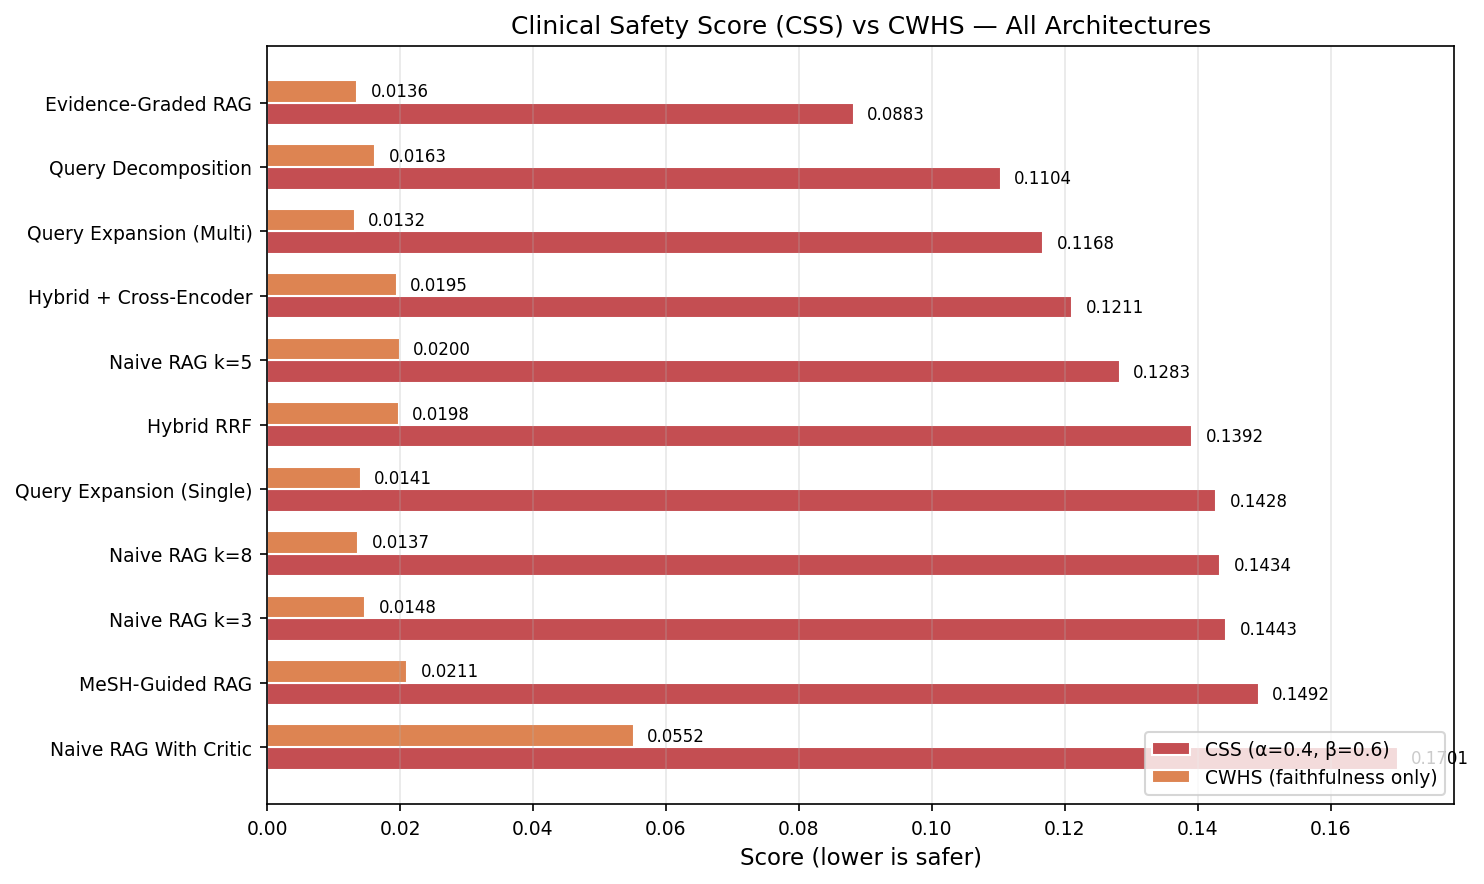

In [48]:
cwhs_full = pd.read_csv(FIGURES_DIR / "cwhs_summary.csv").set_index("Architecture")
css_df = cwhs_full[["CSS", "CWHS"]].dropna().sort_values("CSS", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(css_df))
bar_h = 0.35

bars1 = ax.barh(y - bar_h/2, css_df["CSS"], bar_h, label="CSS (α=0.4, β=0.6)", color="#C44E52", edgecolor="white")
bars2 = ax.barh(y + bar_h/2, css_df["CWHS"], bar_h, label="CWHS (faithfulness only)", color="#DD8452", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(css_df.index)
ax.set_xlabel("Score (lower is safer)")
ax.set_title("Clinical Safety Score (CSS) vs CWHS — All Architectures")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_css_vs_cwhs.png", bbox_inches="tight")
plt.show()

## Chart 19: CSS Rank vs CWHS Rank — Rank Shift When Adding Correctness

Shows how architectures shift in ranking when correctness is incorporated (CSS) vs faithfulness alone (CWHS). Large positive shifts indicate architectures whose answer quality is better than their hallucination rate suggests.

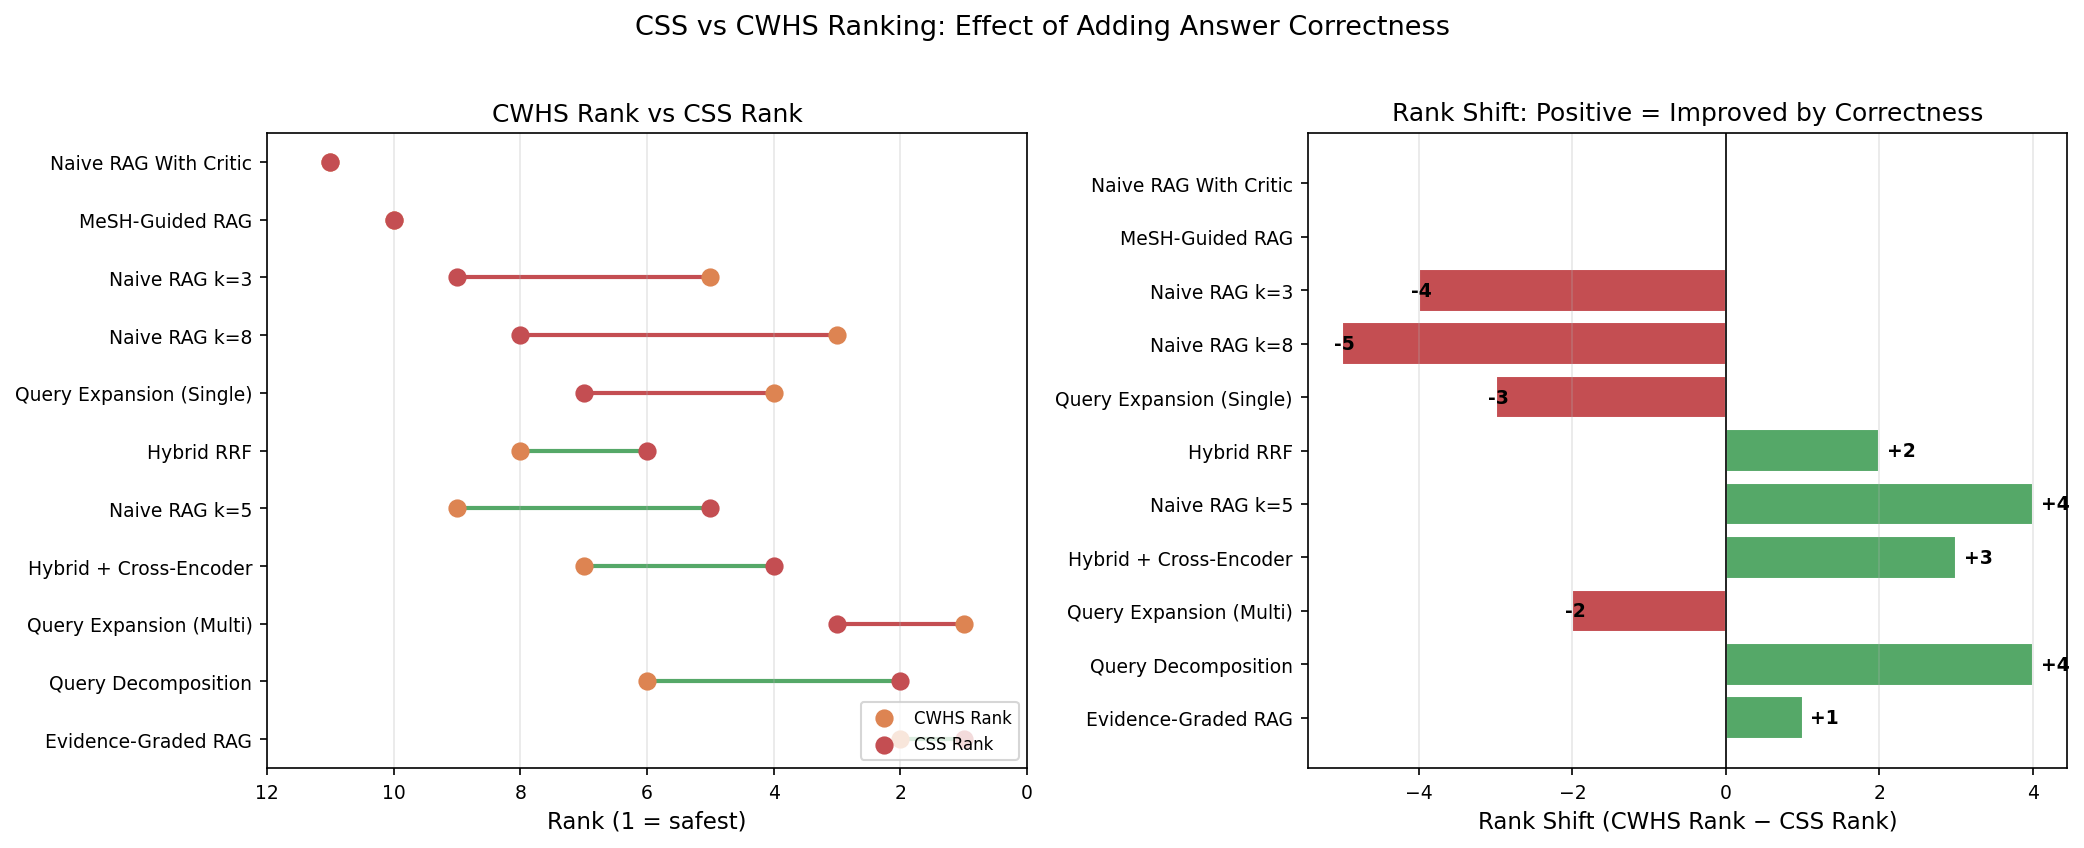

In [49]:
cwhs_ranked = cwhs_full["CWHS"].dropna().rank(ascending=True).astype(int)
css_ranked = cwhs_full["CSS"].dropna().rank(ascending=True).astype(int)

rank_df = pd.DataFrame({"CWHS Rank": cwhs_ranked, "CSS Rank": css_ranked}).dropna()
rank_df["Shift"] = rank_df["CWHS Rank"] - rank_df["CSS Rank"]
rank_df = rank_df.sort_values("CSS Rank")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Dumbbell chart — CWHS rank vs CSS rank
for i, (arch, row) in enumerate(rank_df.iterrows()):
    cwhs_r, css_r = row["CWHS Rank"], row["CSS Rank"]
    color = "#55A868" if row["Shift"] > 0 else "#C44E52" if row["Shift"] < 0 else "#999"
    ax1.plot([cwhs_r, css_r], [i, i], color=color, linewidth=2, zorder=1)
    ax1.scatter(cwhs_r, i, color="#DD8452", s=60, zorder=2, label="CWHS Rank" if i == 0 else "")
    ax1.scatter(css_r, i, color="#C44E52", s=60, zorder=2, label="CSS Rank" if i == 0 else "")

ax1.set_yticks(range(len(rank_df)))
ax1.set_yticklabels(rank_df.index)
ax1.set_xlabel("Rank (1 = safest)")
ax1.set_title("CWHS Rank vs CSS Rank")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(axis="x", alpha=0.3)
ax1.set_xlim(0, len(rank_df) + 1)
ax1.invert_xaxis()

# Right: Diverging bar chart of rank shift
shift_colors = ["#55A868" if s > 0 else "#C44E52" if s < 0 else "#999" for s in rank_df["Shift"]]
bars = ax2.barh(range(len(rank_df)), rank_df["Shift"], color=shift_colors, edgecolor="white")
ax2.set_yticks(range(len(rank_df)))
ax2.set_yticklabels(rank_df.index)
ax2.set_xlabel("Rank Shift (CWHS Rank − CSS Rank)")
ax2.set_title("Rank Shift: Positive = Improved by Correctness")
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, rank_df["Shift"]):
    if val != 0:
        x_pos = bar.get_width() + 0.1 if val > 0 else bar.get_width() - 0.1
        ha = "left" if val > 0 else "right"
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f"{int(val):+d}", va="center", fontsize=9, fontweight="bold")

plt.suptitle("CSS vs CWHS Ranking: Effect of Adding Answer Correctness", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_css_rank_shift.png", bbox_inches="tight")
plt.show()

## Chart 20: Per-Tier Correctness — Answer Quality by Clinical Severity

Shows mean answer correctness within each severity tier per architecture. Architectures that maintain high correctness on High-severity questions are most clinically valuable.

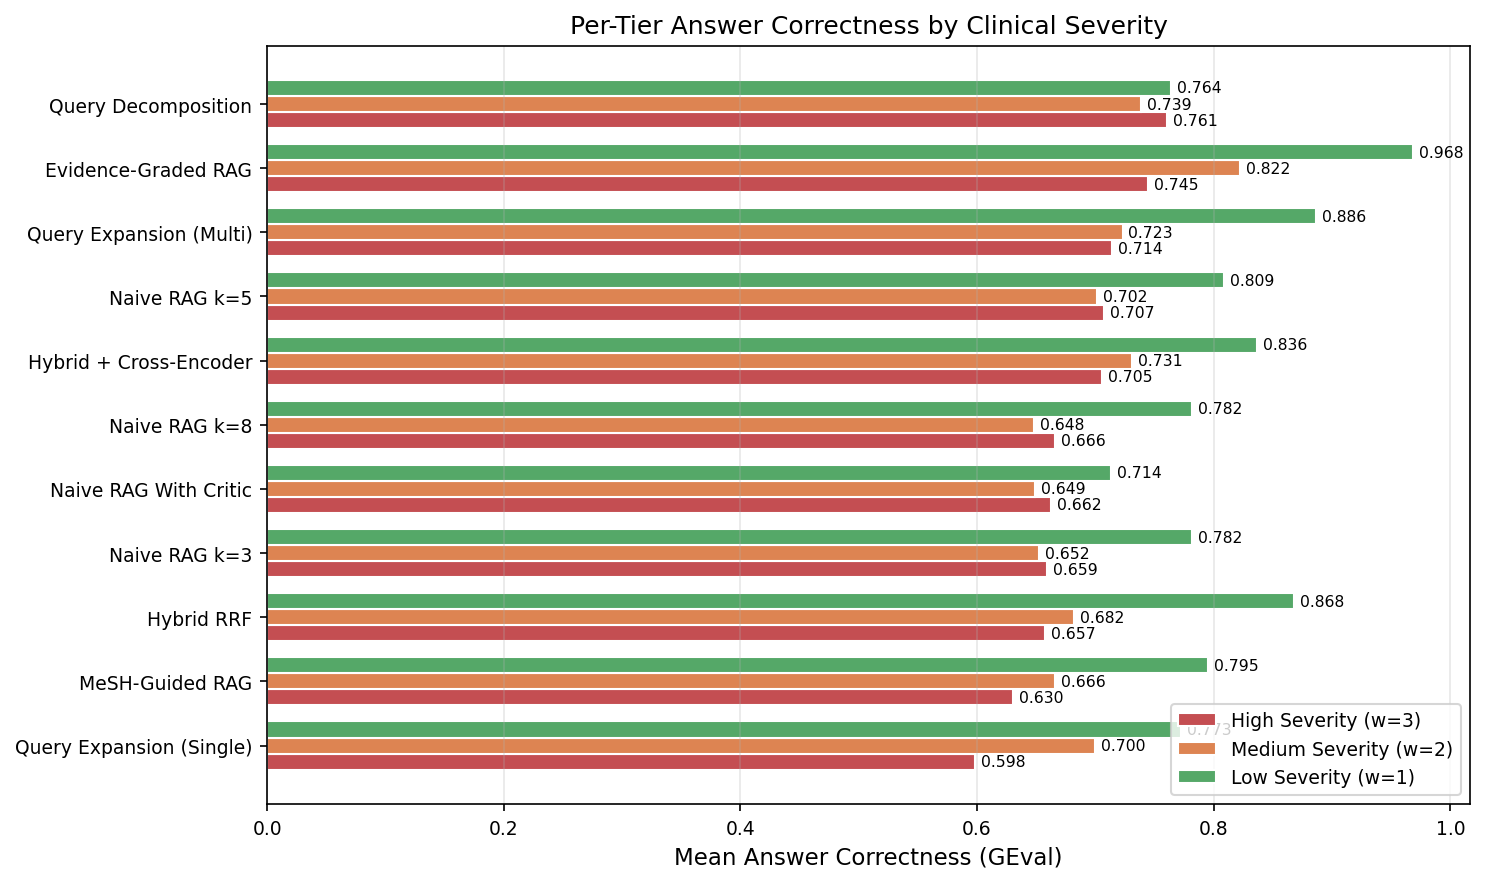

In [50]:
bd_full = pd.read_csv(FIGURES_DIR / "cwhs_breakdown_by_severity.csv").set_index("Architecture")

corr_tiers = ["High Corr.", "Medium Corr.", "Low Corr."]
corr_labels = ["High Severity", "Medium Severity", "Low Severity"]
corr_plot = bd_full[corr_tiers].dropna().sort_values("High Corr.", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(corr_plot))
bar_h = 0.25

bars_h = ax.barh(y - bar_h, corr_plot["High Corr."], bar_h, label="High Severity (w=3)", color="#C44E52", edgecolor="white")
bars_m = ax.barh(y, corr_plot["Medium Corr."], bar_h, label="Medium Severity (w=2)", color="#DD8452", edgecolor="white")
bars_l = ax.barh(y + bar_h, corr_plot["Low Corr."], bar_h, label="Low Severity (w=1)", color="#55A868", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(corr_plot.index)
ax.set_xlabel("Mean Answer Correctness (GEval)")
ax.set_title("Per-Tier Answer Correctness by Clinical Severity")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

for bar in bars_h:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7.5)
for bar in bars_m:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7.5)
for bar in bars_l:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart_css_per_tier_correctness.png", bbox_inches="tight")
plt.show()

In [51]:
shutil.copytree(FIGURES_DIR, "drive/MyDrive/LJMU/results/figures", dirs_exist_ok=True)


'drive/MyDrive/LJMU/results/figures'